
## Scenario 10 — Agentic AI for FSC Linear Multi (eff)

- Framework: Multi-agent
- Decision making: **Gemini** (per-tier LLM calls), **strict JSON schema enforced**.
- Agents pick **discrete policy knobs** only: `alpha`, `service_level`, `expedite`.
- All inventory/forecast math remains **deterministic in code**.
- Linear forward chain.


In [ ]:
# ===== G2 — Setup =====
!pip -q install jsonschema google-generativeai

import os, json
from getpass import getpass

# 1) Read API key
if "GEMINI_API_KEY" not in os.environ or not os.environ["GEMINI_API_KEY"]:
    os.environ["GEMINI_API_KEY"] = getpass("Enter GEMINI_API_KEY: ")

# 2) Bypass any local proxies that may force localhost routing
for var in ["HTTP_PROXY","HTTPS_PROXY","ALL_PROXY","NO_PROXY","http_proxy","https_proxy","all_proxy","no_proxy"]:
    if var in os.environ:
        os.environ.pop(var, None)
# (Optional belt-and-suspenders)
os.environ["NO_PROXY"] = "*"

# 3) Configure client with explicit endpoint
import google.generativeai as genai
genai.configure(
    api_key=os.environ["GEMINI_API_KEY"],
    client_options={"api_endpoint": "https://generativelanguage.googleapis.com"}
)

# 4) Imports
import numpy as np
from dataclasses import dataclass
from typing import Dict, Any, List
from jsonschema import validate, ValidationError

# 5) Test
try:
    mdl = genai.GenerativeModel("gemini-1.5-flash")
    resp = mdl.generate_content("Return the single word: OK", request_options={"timeout": 6})
    print("Smoke test:", (resp.text or "").strip())
except Exception as e:
    print(" Test:", repr(e))

print("Setup complete.")


Enter GEMINI_API_KEY: ··········
Smoke test: OK
Setup complete.


In [ ]:
# ===== R1 — Roles, profiles, project, disruption, InfoBank (GLOBAL - NO DISTANCE WEIGHT) =====
from dataclasses import dataclass, field
from typing import Dict, Any, List, Optional, Tuple
import numpy as np

rng = np.random.default_rng(42)

demand_df = pd.read_csv("data/project_demand.csv")
SUB_COLUMNS = {"Sub1": "project_1_demand", "Sub2": "project_2_demand", "Sub3": "project_3_demand"}

def active_length(series):
    nonzero = np.nonzero(series)[0]
    return (nonzero[-1] + 1) if len(nonzero) else len(series)

raw_subs = {sub: demand_df[col].to_numpy() for sub, col in SUB_COLUMNS.items()}
horizonWeeks = min(active_length(arr) for arr in raw_subs.values())

customerDemand_by_sub = {
    sub: arr[:horizonWeeks].astype(float) for sub, arr in raw_subs.items()
}
# Total demand across all projects
customerDemand_total = np.sum([customerDemand_by_sub[sub] for sub in customerDemand_by_sub.keys()], axis=0)

# ----------------------------------
# Supply chain structure
#   Three parallel project heads: Sub1/PO1, Sub2/PO2, Sub3/PO3
#   Two middle branches: 3PL_A → Dist_A, 3PL_B → Dist_B
#   Single supplier: Sup
# ----------------------------------
SUBS = [f"Sub{i}" for i in range(1, 4)]
POS  = [f"PO{i}"  for i in range(1, 4)]
THREEPLS = ["3PL_A", "3PL_B"]
DISTS    = ["Dist_A", "Dist_B"]
SUPS     = ["Sup"]

ROLES: List[str] = SUBS + POS + THREEPLS + DISTS + SUPS

# Helper to pair Sub_i <-> PO_i
def paired_names(role: str) -> Tuple[Optional[str], Optional[str]]:
    if role.startswith("Sub"):
        i = role.replace("Sub", "")
        return role, f"PO{i}"
    if role.startswith("PO"):
        i = role.replace("PO", "")
        return f"Sub{i}", role
    return None, None

# Neighbor map
# - Each Sub_i sees only its PO_i
# - Each PO_i sees Sub_i and both 3PLs (choice will be handled later)
# - 3PL_A sees all POs and Dist_A; 3PL_B sees all POs and Dist_B
# - Dist_A sees 3PL_A and Sup; Dist_B sees 3PL_B and Sup
# - Sup sees both distributors
NEIGHBORS: Dict[str, List[str]] = {}
for i in range(1, 4):
    NEIGHBORS[f"Sub{i}"] = [f"PO{i}"]
    NEIGHBORS[f"PO{i}"]  = [f"Sub{i}", "3PL_A", "3PL_B"]

NEIGHBORS["3PL_A"] = POS + ["Dist_A"]
NEIGHBORS["3PL_B"] = POS + ["Dist_B"]
NEIGHBORS["Dist_A"] = ["3PL_A", "Sup"]
NEIGHBORS["Dist_B"] = ["3PL_B", "Sup"]
NEIGHBORS["Sup"] = ["Dist_A", "Dist_B"]

@dataclass
class Profile:
    name: str
    policy_version: int = 0
    share_keys: List[str] = field(default_factory=list)

# Share policy (same intent as before; cloned per-role)
profiles: Dict[str, Profile] = {}
for s in SUBS:
    profiles[s] = Profile(s, share_keys=["backlog"])
for p in POS:
    profiles[p] = Profile(p, share_keys=["backlog", "pipeline"])
profiles["3PL_A"] = Profile("3PL_A", share_keys=["pipeline"])
profiles["3PL_B"] = Profile("3PL_B", share_keys=["pipeline"])
profiles["Dist_A"] = Profile("Dist_A", share_keys=["on_hand", "backlog"])
profiles["Dist_B"] = Profile("Dist_B", share_keys=["on_hand", "backlog"])
profiles["Sup"]    = Profile("Sup",    share_keys=["on_hand", "pipeline"])

# Keep only used project info
project = {"id": "P1", "material": "Rebar#5"}

disruption = {"week": 30, "delta_leadtime": 2, "duration_weeks": 8}

# Keep only used noise parameter
leadtime_noise = 0.0

def degrade_obs(x: float, rel_std: float, rng) -> float:
    return float(max(0.0, x * (1.0 + rng.normal(0.0, rel_std))))

# Small helpers to interpret role names
def role_type(role: str) -> str:
    if role.startswith("Sub"): return "Sub"
    if role.startswith("PO"):  return "PO"
    if role.startswith("3PL"): return "3PL"
    if role.startswith("Dist"):return "Dist"
    if role == "Sup":          return "Sup"
    return role

def dist_branch(role: str) -> Optional[str]:
    # returns "A" or "B" for Dist/3PL
    if role.startswith("3PL_"):  return role.split("_")[1]
    if role.startswith("Dist_"): return role.split("_")[1]
    return None

class InfoBank:
    def __init__(self, profiles: Dict[str, Profile], rng, info_regime: str = "global"):
        if info_regime not in ["local", "global"]:
            raise ValueError("info_regime must be 'local' or 'global'")
        self.profiles = profiles
        self.rng = rng
        self.info_regime = info_regime
        self.local: Dict[str, Dict[str, Any]] = {r: {} for r in ROLES}

        # Shared views
        if info_regime == "local":
            # Each receiver keeps neighbors' shared data
            self.shared: Dict[str, Dict[str, Dict[str, Any]]] = {
                role: {neighbor: {} for neighbor in NEIGHBORS.get(role, [])}
                for role in ROLES
            }
        else:
            self.shared: Dict[str, Dict[str, Any]] = {r: {} for r in ROLES}

        # Lead times (same as before, split per branch where needed)
        self.true_lead: Dict[str, int] = {
            "Sup->Dist_A": 3,
            "Sup->Dist_B": 3,
            "Dist_A->3PL_A": 1,
            "Dist_B->3PL_B": 1,
            # both 3PL branches to any PO have the same nominal LT
            "3PL->PO": 1,
            # each PO_i to its Sub_i
            "PO->Sub": 0,
        }
        self.time = 0

    def apply_disruption(self, t: int):
        # Same disruption as base: affects Sup -> Dist only
        if t == disruption["week"]:
            self.true_lead["Sup->Dist_A"] += disruption["delta_leadtime"]
            self.true_lead["Sup->Dist_B"] += disruption["delta_leadtime"]
        if t == disruption["week"] + disruption["duration_weeks"]:
            self.true_lead["Sup->Dist_A"] -= disruption["delta_leadtime"]
            self.true_lead["Sup->Dist_B"] -= disruption["delta_leadtime"]

    def update_share_policy(self, role: str, add_keys: Optional[List[str]] = None, drop_keys: Optional[List[str]] = None):
        p = self.profiles[role]
        if add_keys:
            for k in add_keys:
                if k not in p.share_keys and k in ["on_hand", "backlog", "pipeline"]:
                    p.share_keys.append(k)
        if drop_keys:
            p.share_keys = [k for k in p.share_keys if k not in drop_keys]
        p.policy_version += 1

    def publish(self, role: str):
        """Publish according to information regime"""
        policy_keys = set(self.profiles[role].share_keys)
        shared_data = {k: self.local[role].get(k) for k in policy_keys if k in self.local[role]}

        if self.info_regime == "local":
            for neighbor in NEIGHBORS.get(role, []):
                if neighbor in ROLES:
                    if neighbor not in self.shared:
                        self.shared[neighbor] = {}
                    self.shared[neighbor][role] = shared_data.copy()
        else:
            self.shared[role] = shared_data.copy()

    def context_view_for(self, role: str) -> Dict[str, Any]:
        view = {
            "role": role,
            "t": self.time,
            "project_id": project["id"],
            "material": project["material"]
        }
        view[f"{role}_self"] = {k: self.local[role].get(k) for k in self.local[role].keys()}

        if self.info_regime == "local":
            visible_roles = NEIGHBORS.get(role, [])
            for neighbor_role in visible_roles:
                neighbor_shared_data = self.shared.get(role, {}).get(neighbor_role, {})
                view[f"{neighbor_role}_shared"] = neighbor_shared_data
        else:
            visible_roles = [r for r in ROLES if r != role]
            for r in visible_roles:
                view[f"{r}_shared"] = self.shared.get(r, {}).copy()

        view["my_profile"] = {"policy_version": self.profiles[role].policy_version}
        view["info_regime_context"] = {
            "regime": self.info_regime,
            "visible_roles": visible_roles,
            "total_network_size": len(ROLES)
        }
        return view

    def _get_shared_insights(self, role: str) -> Dict[str, float]:
        """Aggregate coarse insights from shared data."""
        downstream_backlog = 0.0
        upstream_inventory = 0.0
        visible_partners = []

        # Position map along the generic direction Sup -> ... -> Sub
        chain_order = {"Sup": 0, "Dist_A": 1, "Dist_B": 1, "3PL_A": 2, "3PL_B": 2,
                       "PO": 3, "Sub": 4}
        rt = role_type(role)
        my_position = chain_order.get(rt, 2)

        if self.info_regime == "local":
            neighbors = NEIGHBORS.get(role, [])
            for neighbor_role in neighbors:
                shared_data = self.shared.get(role, {}).get(neighbor_role, {})
                if shared_data:
                    visible_partners.append(neighbor_role)
                    nr_type = role_type(neighbor_role)
                    partner_position = chain_order.get(nr_type, 2)

                    if partner_position > my_position and "backlog" in shared_data:
                        downstream_backlog += float(shared_data["backlog"])
                    if partner_position < my_position and "on_hand" in shared_data:
                        upstream_inventory += float(shared_data["on_hand"])
        else:
            # Global regime: no distance weighting - equal access to all roles
            visible_roles = [r for r in ROLES if r != role]
            for visible_role in visible_roles:
                shared_data = self.shared.get(visible_role, {})
                if not shared_data:
                    continue
                visible_partners.append(visible_role)

                vr_type = role_type(visible_role)
                partner_position = chain_order.get(vr_type, 2)

                if partner_position > my_position and "backlog" in shared_data:
                    downstream_backlog += float(shared_data["backlog"])
                if partner_position < my_position and "on_hand" in shared_data:
                    upstream_inventory += float(shared_data["on_hand"])

        return {
            "downstream_backlog": downstream_backlog,
            "upstream_inventory": upstream_inventory,
            "visible_partners": len(visible_partners)
        }

    def math_signals_for(self, role: str, hist: Dict[str, Dict[str, np.ndarray]], window: int = 8) -> Dict[str, Any]:
        t = self.time
        rtype = role_type(role)

        # Determine downstream orders signal by role type
        if rtype == "Sub":
            # Use that sub's own customer demand series
            downstream_orders = np.asarray(customerDemand_by_sub[role], dtype=float)
        elif rtype == "PO":
            # Orders from its paired Sub_i if available; fallback to that sub's demand
            sub_i, _ = paired_names(role)
            if "orders_out" in hist and sub_i in hist.get("orders_out", {}):
                downstream_orders = np.asarray(hist["orders_out"][sub_i], dtype=float)
            else:
                downstream_orders = np.asarray(customerDemand_by_sub[sub_i], dtype=float)
        elif rtype == "3PL":
            # Aggregate PO orders (all POs) as downstream demand proxy
            if "orders_out" in hist:
                po_keys = [k for k in hist["orders_out"].keys() if k.startswith("PO")]
                if po_keys:
                    downstream_orders = np.sum([np.asarray(hist["orders_out"][k], dtype=float) for k in po_keys], axis=0)
                else:
                    downstream_orders = np.asarray(customerDemand_total, dtype=float)
            else:
                downstream_orders = np.asarray(customerDemand_total, dtype=float)
        elif rtype == "Dist":
            # Use orders from its 3PL branch only
            my_branch = dist_branch(role)
            tpl_key = f"3PL_{my_branch}"
            if "orders_out" in hist and tpl_key in hist["orders_out"]:
                downstream_orders = np.asarray(hist["orders_out"][tpl_key], dtype=float)
            else:
                downstream_orders = np.asarray(customerDemand_total, dtype=float)
        elif rtype == "Sup":
            # Use both distributors' orders if present; else a conservative proxy
            if "orders_out" in hist:
                ds = []
                if "Dist_A" in hist["orders_out"]: ds.append(np.asarray(hist["orders_out"]["Dist_A"], dtype=float))
                if "Dist_B" in hist["orders_out"]: ds.append(np.asarray(hist["orders_out"]["Dist_B"], dtype=float))
                if ds:
                    downstream_orders = np.sum(ds, axis=0)
                else:
                    downstream_orders = np.asarray(customerDemand_total, dtype=float)
            else:
                downstream_orders = np.asarray(customerDemand_total, dtype=float)
        else:  # unknown role
            downstream_orders = np.zeros_like(np.asarray(customerDemand_total, dtype=float))

        # Demand window stats
        win = downstream_orders[max(0, t-window):t+1]
        dmean = float(win.mean()) if win.size else 0.0
        dstd  = float(win.std(ddof=0)) if win.size else 0.0

        # Shared insights
        shared_insights = self._get_shared_insights(role)

        # Global info sharing = direct access to project schedules
        if self.info_regime == "global":
            if rtype == "Sub":
                # Each sub sees its own project schedule
                schedule_window = customerDemand_by_sub[role][max(0, t-window):min(len(customerDemand_by_sub[role]), t+8)]
            else:
                # Other roles see total project demand
                schedule_window = customerDemand_total[max(0, t-window):min(len(customerDemand_total), t+8)]

            if len(schedule_window) > 0:
                dmean = float(schedule_window[:window+1].mean())
                dstd = float(schedule_window[:window+1].std())

        # Perfect visibility of own inventory position
        inv = float(self.local[role].get("on_hand", 0.0))
        bkl = float(self.local[role].get("backlog", 0.0))
        pip = float(self.local[role].get("pipeline", 0.0))
        invpos_obs = inv + pip - bkl

        # Lead time estimate (by link)
        # Note: both 3PL branches have LT=1 to PO; each Dist branch has LT=1 to its 3PL; Sup->Dist_A/B=3 (subject to disruption).
        link = None
        if rtype == "PO":   link = "3PL->PO"
        if rtype == "3PL":  link = f"Dist_{dist_branch(role)}->3PL_{dist_branch(role)}"
        if rtype == "Dist": link = f"Sup->Dist_{dist_branch(role)}"
        if rtype == "Sub":  link = "PO->Sub"

        if link is None:
            L_obs = 0.0
        else:
            L_true = self.true_lead[link]
            L_obs = degrade_obs(L_true, leadtime_noise, self.rng)

        return {
            "t": t,
            "downstream_mean_obs": dmean,
            "downstream_std_obs": dstd,
            "inventory_position_obs": invpos_obs,
            "lead_time_obs": float(L_obs),
            "shared_visibility": shared_insights["visible_partners"],
            "info_regime": self.info_regime,
        }

    def view_for_agent(self, role: str, hist: Dict[str, Dict[str, np.ndarray]], window: int = 8) -> Dict[str, Any]:
        return {
            "context_view": self.context_view_for(role),
            "math_signals": self.math_signals_for(role, hist, window),
        }

In [ ]:
# ===== R2 — Cleaned LLM Agent Decision Making =====
import json
from typing import Dict, Any, List
import math
import time
import numpy as np
import google.generativeai as genai

# ----------------------------
# Valid information sharing keys
# ----------------------------
allowed_share_keys = {"on_hand", "backlog", "pipeline"}

# ----------------------------
# Schema-less, deterministic model (matches 1-project GLOBAL)
# ----------------------------
gemini_coeff_fixed = genai.GenerativeModel(
    model_name="gemini-1.5-flash",
    generation_config=genai.GenerationConfig(
        temperature=0.0,                     # deterministic for research runs
        response_mime_type="application/json"
    ),
    system_instruction=(
        "You are a role-bound decision maker in a multi-agent construction supply chain simulation. "
        "Always output valid JSON with numeric values within the specified ranges. No prose."
    ),
)

REQUIRED_KEYS = {"alpha", "service_level", "lot_multiplier", "expedite", "share_add", "share_drop"}

# ----------------------------
# Validation
# ----------------------------
def validate_coeffs(obj: Dict[str, Any]) -> Dict[str, Any]:
    # Fill optional keys if missing
    obj = {**{"share_add": [], "share_drop": []}, **obj}

    # Enforce exact key set
    keys = set(obj.keys())
    missing = {"alpha","service_level","lot_multiplier","expedite"} - keys
    extras = keys - REQUIRED_KEYS
    if missing:
        raise ValueError(f"Missing required keys: {sorted(missing)}")
    if extras:
        raise ValueError(f"Extra keys not allowed: {sorted(extras)}")

    # Type & domain checks
    if not isinstance(obj["alpha"], (int, float)) or not (0.05 <= float(obj["alpha"]) <= 0.50):
        raise ValueError(f"alpha {obj['alpha']} must be a number in [0.05, 0.50]")
    if not isinstance(obj["service_level"], (int, float)) or not (0.80 <= float(obj["service_level"]) <= 0.95):
        raise ValueError(f"service_level {obj['service_level']} must be a number in [0.80, 0.95]")
    if not isinstance(obj["lot_multiplier"], (int, float)) or not (0.50 <= float(obj["lot_multiplier"]) <= 2.00):
        raise ValueError(f"lot_multiplier {obj['lot_multiplier']} must be a number in [0.50, 2.00]")
    if not isinstance(obj["expedite"], bool):
        raise ValueError(f"expedite {obj['expedite']} must be true or false")

    # Validate sharing keys
    for k in ("share_add", "share_drop"):
        if not isinstance(obj[k], list):
            raise ValueError(f"{k} must be a list")
        bad = [x for x in obj[k] if x not in allowed_share_keys]
        if bad:
            raise ValueError(f"{k} contains invalid keys: {bad}")

    # Round to two decimals for cleanliness
    obj["alpha"] = round(float(obj["alpha"]), 2)
    obj["service_level"] = round(float(obj["service_level"]), 2)
    obj["lot_multiplier"] = round(float(obj["lot_multiplier"]), 2)
    return obj

# ----------------------------
# Role strategies (generic — maps Sub1→Sub, 3PL_A→3PL, Dist_B→Dist, etc.)
# ----------------------------
ROLE_STRATEGIES = {
    "Sub": {
        "position": "End consumer: directly faces project demand",
        "key_pressure": "Crew idle time is highly costly; stockouts cause immediate work stoppage",
        "inventory_reality": "Very limited on-site storage; frequent deliveries are necessary",
        "optimal_strategy": "Maintain high responsiveness to demand changes while avoiding overstock; prefer smaller, more frequent orders",
        "decision_drivers": "React quickly to schedule changes and minimize storage-related risk"
    },
    "PO": {
        "position": "Specialized procurement function: natural broker",
        "key_pressure": "Bridge between design specs and supplier capabilities despite limited authority",
        "inventory_reality": "Minimal direct inventory control; focused on specification and sourcing",
        "optimal_strategy": "Leverage brokerage position to coordinate early supplier engagement while working within limited organizational mandate",
        "decision_drivers": "Navigate structural holes between production, oversight, and execution while building case for expanded coordination role"
    },
    "3PL": {
        "position": "Material consolidation yard: aggregates shipments and manages delivery timing",
        "key_pressure": "Consolidation efficiency versus delivery responsiveness; balancing batch economies with urgency",
        "inventory_reality": "Short-term staging for consolidation; costs rise with holding time but efficiency improves with larger batches",
        "optimal_strategy": "Balance quick response to urgent orders against waiting to consolidate efficient full loads; smooth irregular upstream deliveries into steady downstream flow",
        "decision_drivers": "Trade off immediate delivery against consolidation savings; manage variability between lumpy supplier deliveries and steady customer needs"
    },
    "Dist": {
        "position": "Regional warehouse: serves multiple customers and buffers variability",
        "key_pressure": "Significant holding costs versus reputational risk from service failures",
        "inventory_reality": "Large capacity but costly to maintain at high occupancy",
        "optimal_strategy": "Smooth variability, uphold high service reliability, and consolidate orders for efficiency",
        "decision_drivers": "Optimize storage efficiency while safeguarding customer retention"
    },
    "Sup": {
        "position": "Production facility: furthest upstream from end demand",
        "key_pressure": "High setup and holding costs; frequent changeovers reduce efficiency",
        "inventory_reality": "Capacity and scheduling constraints; efficiency improves with longer runs",
        "optimal_strategy": "Stabilize production with longer, consistent runs while keeping enough inventory to ensure downstream reliability",
        "decision_drivers": "Reduce changeovers, maintain production efficiency, and provide dependable supply"
    }
}

# ----------------------------
# Helpers
# ----------------------------
def _role_type(role: str) -> str:
    if role.startswith("Sub"):  return "Sub"
    if role.startswith("PO"):   return "PO"
    if role.startswith("3PL"):  return "3PL"
    if role.startswith("Dist"): return "Dist"
    if role == "Sup":           return "Sup"
    # No fallback
    raise ValueError(f"Unknown role '{role}'. Allowed: {list(ROLE_STRATEGIES.keys())}")


# ----------------------------
# Prompt builder
# ----------------------------
def _create_role_specific_prompt(role: str, view: Dict[str, Any]) -> str:
    rt = _role_type(role)
    strategy = ROLE_STRATEGIES[rt]

    ctx = view.get("context_view", {})
    ms  = view.get("math_signals", {})

    week = int(ms.get("t", ctx.get("t", 0)))
    info_regime = ms.get("info_regime", ctx.get("info_regime_context", {}).get("regime", "local"))
    visible_ct  = int(ms.get("shared_visibility", 0))

    # Signals
    dmean = float(ms.get("downstream_mean_obs", 0.0))
    dstd  = float(ms.get("downstream_std_obs", 0.0))
    invpos = float(ms.get("inventory_position_obs", 0.0))
    L_obs = float(ms.get("lead_time_obs", 0.0))


    decision_glossary = f"""
Critical: All values must be in these exact ranges

Decision knobs (numeric):
- responsiveness (alpha) in [0.05, 0.50]
  Meaning: weight on recent demand signals vs. historical smoothing.
  Higher= reacts faster to changes; Lower= smooths noise and favors stability.
- service_level in [0.80, 0.95]
  Meaning: reliability target for avoiding stockout before replenishment.
  Higher= fewer stockouts but more inventory; Lower= leaner inventory with higher risk.
- lot_multiplier in [0.50, 2.00]
  Meaning: order/batch size relative to a nominal order.
  Higher= larger, less frequent orders (efficiency, less flexibility); Lower= smaller, more frequent orders (flexibility, more ordering overhead).
- expedite in {{true,false}}
  Meaning: pay a premium to shorten delay when stockout risk is material.
- share_add / share_drop are subsets of {sorted(list(allowed_share_keys))}
  Meaning: information you will start/stop sharing this week to improve coordination.

Constraints:
- Provide numeric values only (two decimals max) for alpha, service_level, and lot_multiplier.
- Stay within the ranges above; if you would go outside, choose the nearest bound.
- Base choices on this week's signals (volatility, cover, backlog, lead-time), not on assumptions.
"""

    prompt = f"""You are operating as: {strategy['position']} (week {week}).

Role context:
- Key pressure: {strategy['key_pressure']}
- Inventory reality: {strategy['inventory_reality']}
- Recommended stance (qualitative): {strategy['optimal_strategy']}
- Decision drivers: {strategy['decision_drivers']}

{decision_glossary}

OUTPUT (valid JSON only; no prose):
{{
  "alpha": <number>,
  "service_level": <number>,
  "lot_multiplier": <number>,
  "expedite": <true|false>,
  "share_add": <list of strings from allowed keys>,
  "share_drop": <list of strings from allowed keys>
}}"""
    return prompt

# ----------------------------
# LLM call with retries
# ----------------------------
def llm_choose_coeffs(role: str, view: Dict[str, Any]) -> Dict[str, Any]:
    """Call LLM with role-specific prompts; validate and return numeric coefficients."""
    prompt = _create_role_specific_prompt(role, view)

    last_err = None
    for attempt in range(5):  # initial + up to 4 retries
        try:
            # gentle backoff after first try
            if attempt:
                time.sleep(min(12, 2 ** attempt + float(np.random.uniform(0, 0.5))))

            resp = gemini_coeff_fixed.generate_content([prompt])
            text = (getattr(resp, "text", "") or "").strip()

            # Clean accidental code fences
            if text.startswith("```json"):
                text = text[7:]
            if text.endswith("```"):
                text = text[:-3]
            text = text.strip()

            obj = json.loads(text)
            return validate_coeffs(obj)

        except Exception as e:
            last_err = e
            continue

    # If all retries fail, raise the last validation/parsing error
    raise ValueError(f"LLM output could not be validated after retries: {last_err}")


In [ ]:
# ===== R3 — Supply Chain Formulas =====
import numpy as np
from scipy import stats

def zFromServiceLevel(p: float) -> float:
    """
    Convert service level to z-score using inverse normal distribution.
    """
    if not (0.5 <= p <= 0.999):
        raise ValueError(f"Service level {p} must be between 0.5 and 0.999")
    return float(stats.norm.ppf(p))

def update_forecast(prev_forecast: float, signal_mean_obs: float, alpha: float) -> float:
    """Exponential smoothing driven by observed mean demand."""
    return alpha * signal_mean_obs + (1.0 - alpha) * prev_forecast

def base_stock_target(mu_hat: float, dstd_obs: float, L_obs: float, z: float) -> float:
    """
    Uses (L_obs + 1) convention (cycle + pipeline).
    """
    mean_LT = mu_hat * (L_obs + 1.0)
    std_LT  = dstd_obs * np.sqrt(max(0.0, L_obs + 1.0))
    return mean_LT + z * std_LT

def compute_order_qty(invpos_obs: float, target: float, lot_multiplier: float) -> float:
    """
    Gap-based ordering with a lot-size multiplier (agent-chosen).
    """
    gap = max(0.0, target - invpos_obs)
    return max(0.0, lot_multiplier * gap)

In [ ]:
# ===== R4 — Simulation Runner (multi-project, dual 3PL/Dist) =====
from typing import Dict, Any, List, Tuple
import numpy as np

# -------- Helpers --------
def role_type(role: str) -> str:
    if role.startswith("Sub"):  return "Sub"
    if role.startswith("PO"):   return "PO"
    if role.startswith("3PL"):  return "3PL"
    if role.startswith("Dist"): return "Dist"
    if role == "Sup":           return "Sup"
    return role

def paired_names(role: str) -> Tuple[str, str]:
    if role.startswith("Sub"):
        i = role.replace("Sub", "")
        return role, f"PO{i}"
    if role.startswith("PO"):
        i = role.replace("PO", "")
        return f"Sub{i}", role
    return "", ""

def dist_branch(role: str) -> str:
    if role.startswith("3PL_"):  return role.split("_")[1]
    if role.startswith("Dist_"): return role.split("_")[1]
    return ""

# -------- Routing review cadence (periodic, unsynchronized) --------
ROUTE_REVIEW_PERIOD = 10
UNSYNCED_REVIEW     = True # each PO gets its own phase

def init_po_review_phases(POS: List[str], period: int, rng) -> Dict[str, int]:
    """
    Pick per-PO phases in [0, period-1] to avoid lockstep reviews.
    Hardened for any (#PO, period) combo.
    """
    if not UNSYNCED_REVIEW or period <= 0:
        return {po: 0 for po in POS}
    return {po: int(rng.integers(0, period)) for po in POS}

# -------- Constraints --------
def apply_realistic_constraints(role: str, raw_order_qty: float, ms: dict, t: int) -> float:
    """
    Apply realistic inventory constraints to prevent unrealistic ordering behavior.
    Supplier: no forced minimum ordering.
    """
    weekly_demand = max(1.0, ms["downstream_mean_obs"])
    current_inventory = ms["inventory_position_obs"]

    rt = role_type(role)
    if rt == "Dist":
        max_inventory = weekly_demand * 3.0
    elif rt == "Sup":
        max_inventory = weekly_demand * 2.5
    elif rt == "3PL":
        max_inventory = weekly_demand * 2.0
    else:
        max_inventory = weekly_demand * 4.0

    max_single_order = weekly_demand * 1.5

    if current_inventory > max_inventory:
        constrained_qty = 0.0
    else:
        max_by_capacity = max(0.0, max_inventory - current_inventory)
        constrained_qty = min(raw_order_qty, max_single_order, max_by_capacity)

        if rt != "Sup":
            min_inventory_threshold = weekly_demand
            if current_inventory < min_inventory_threshold and constrained_qty < weekly_demand * 0.5:
                constrained_qty = max(constrained_qty, weekly_demand * 0.5)

    return float(max(0.0, constrained_qty))

# -------- Simulation --------
def run_construction_scenario(
    T: int,
    info_bank: InfoBank,
    rng,
    window: int = 8,
    sup_production_lead: int = 1,
):
    # Role sets should already be defined in R1: ROLES, SUBS, POS, THREEPLS, DISTS, SUPS
    assert T == horizonWeeks, "Expected T to match horizonWeeks for demand arrays"

    # -- Active roles --
    ROLES_ACTIVE = [r for r in ROLES]

    # -- Routing state (PO -> 3PL_A/B) --
    routing_choice: Dict[str, str] = {po: "3PL_A" for po in POS}
    po_review_phase = init_po_review_phases(POS, ROUTE_REVIEW_PERIOD, rng)

    # -- Histories --
    hist = {
        "on_hand":       {r: np.zeros(T, dtype=float) for r in ROLES},
        "backlog":       {r: np.zeros(T, dtype=float) for r in ROLES},
        "pipeline":      {r: np.zeros(T, dtype=float) for r in ROLES},
        "orders_in":     {r: np.zeros(T, dtype=float) for r in ROLES},
        "orders_out":    {r: np.zeros(T, dtype=float) for r in ROLES},
        "shipments_in":  {r: np.zeros(T, dtype=float) for r in ROLES},
        "shipments_out": {r: np.zeros(T, dtype=float) for r in ROLES},
    }
    arrivals = {r: np.zeros(T + 16, dtype=float) for r in ROLES}

    # -- Initial states --
    for r in ROLES:
        rt = role_type(r)
        info_bank.local[r]["on_hand"]  = 5.0 if rt == "Sub" else 8.0 if rt == "PO" else 4.0 if rt == "3PL" else 3.0 if rt == "Dist" else 6.0 if rt == "Sup" else 0.0
        info_bank.local[r]["backlog"]  = 0.0
        info_bank.local[r]["pipeline"] = 0.0

        hist["on_hand"][r][0]  = float(info_bank.local[r]["on_hand"])
        hist["backlog"][r][0]  = 0.0
        hist["pipeline"][r][0] = 0.0

    # -- Forecasts (robust to multi-project) --
    forecast = {r: np.zeros(T, dtype=float) for r in ROLES}
    n0 = max(1, min(10, T))
    try:
        base = np.asarray(customerDemand_total[:n0], dtype=float)
    except NameError:
        base = np.zeros(n0, dtype=float)
        for s in SUBS:  # sum per-project Sub demand
            base += np.asarray(customerDemand_by_sub[s][:n0], dtype=float)
    init_mean = float(base.mean())
    for r in ROLES:
        forecast[r][0] = init_mean

    coeff_logs: Dict[str, List[Dict[str, Any]]] = {r: [] for r in ROLES}
    pipeline_now = {r: hist["pipeline"][r][0] for r in ROLES}
    orders_in_components: Dict[str, Dict[str, float]] = {r: {} for r in ROLES}

    for t in range(T):
        info_bank.time = t
        info_bank.apply_disruption(t)

        # -- Arrivals land --
        for r in ROLES:
            a = float(arrivals[r][t])
            if a > 0:
                hist["shipments_in"][r][t] += a
                hist["on_hand"][r][t]      += a
                pipeline_now[r]             = max(0.0, pipeline_now[r] - a)

        # -- PO routing review happens BEFORE ordering (periodic, unsynchronized) --
        bA = float(info_bank.local.get("3PL_A", {}).get("backlog", 0.0))
        bB = float(info_bank.local.get("3PL_B", {}).get("backlog", 0.0))
        for po in POS:
            if (t % ROUTE_REVIEW_PERIOD) == po_review_phase[po]:
                current = routing_choice[po]
                better  = "3PL_A" if bA < bB else "3PL_B" if bB < bA else current
                routing_choice[po] = better

        # -- Compute orders_in from last week's orders_out --
        for r in ROLES:
            orders_in_components[r] = {}
            rt = role_type(r)

            if rt == "Sub":
                demand_t = float(customerDemand_by_sub[r][t])

            elif rt == "PO":
                sub, _ = paired_names(r)
                prev = float(hist["orders_out"][sub][t-1]) if t > 0 else 0.0
                if prev > 0: orders_in_components[r][sub] = prev
                demand_t = prev

            elif rt == "3PL":
                branch = r.split("_")[1]
                total = 0.0
                for po in POS:
                    if routing_choice[po] == f"3PL_{branch}":
                        prev = float(hist["orders_out"][po][t-1]) if t > 0 else 0.0
                        if prev > 0:
                            orders_in_components[r][po] = prev
                            total += prev
                demand_t = total

            elif rt == "Dist":
                tpl = f"3PL_{dist_branch(r)}"
                prev = float(hist["orders_out"][tpl][t-1]) if t > 0 else 0.0
                if prev > 0: orders_in_components[r][tpl] = prev
                demand_t = prev

            elif rt == "Sup":
                total = 0.0
                for d in DISTS:
                    prev = float(hist["orders_out"][d][t-1]) if t > 0 else 0.0
                    if prev > 0:
                        orders_in_components[r][d] = prev
                        total += prev
                demand_t = total

            else:
                demand_t = 0.0

            hist["orders_in"][r][t] = demand_t

        # -- Shipments & backlog update --
        for r in ROLES:
            if role_type(r) == "GC":
                continue
            need = hist["backlog"][r][t] + hist["orders_in"][r][t]
            ship = min(hist["on_hand"][r][t], need)
            hist["shipments_out"][r][t] = ship
            hist["on_hand"][r][t]      -= ship
            hist["backlog"][r][t]       = need - ship

        # -- Sync state back to InfoBank --
        for r in ROLES:
            info_bank.local[r]["on_hand"]  = float(hist["on_hand"][r][t])
            info_bank.local[r]["backlog"]  = float(hist["backlog"][r][t])
            info_bank.local[r]["pipeline"] = float(pipeline_now[r])

        # -- LLM decisions & ordering (ACTIVE ROLES ONLY) --
        for r in ROLES_ACTIVE:
            view = info_bank.view_for_agent(r, hist, window=window)
            coeffs = llm_choose_coeffs(r, view)
            coeff_logs[r].append({"t": t, **coeffs})

            # Apply sharing policy changes & publish
            if coeffs.get("share_add") or coeffs.get("share_drop"):
                info_bank.update_share_policy(r, add_keys=coeffs.get("share_add"), drop_keys=coeffs.get("share_drop"))
            info_bank.publish(r)

            if role_type(r) == "Sub":
                q = max(0.0, float(customerDemand_by_sub[r][t]))
            else:
                ms = view["math_signals"]
                mu_prev = forecast[r][t-1] if t > 0 else forecast[r][0]
                mu_hat  = update_forecast(mu_prev, ms["downstream_mean_obs"], coeffs["alpha"])
                forecast[r][t] = mu_hat

                z = zFromServiceLevel(min(coeffs["service_level"], 0.88))
                target = base_stock_target(mu_hat, ms["downstream_std_obs"], ms["lead_time_obs"], z)
                raw_q  = compute_order_qty(ms["inventory_position_obs"], target, min(coeffs["lot_multiplier"], 1.25))

                q = apply_realistic_constraints(r, raw_q, ms, t)

            if bool(coeffs["expedite"]) and hist["backlog"][r][t] > 0:
                exp_now = min(q * 0.25, hist["backlog"][r][t])
                hist["shipments_in"][r][t] += exp_now
                hist["on_hand"][r][t]      += exp_now

            hist["orders_out"][r][t] = q

            # Supplier production lead
            if r == "Sup":
                prod_lead = int(max(0, sup_production_lead))
                t_arr_sup = t + prod_lead
                if t_arr_sup < len(arrivals["Sup"]) and q > 0:
                    arrivals["Sup"][t_arr_sup] += q
                    pipeline_now["Sup"] += q

        # -- Schedule shipments to downstreams (branch-aware, proportional allocation) --
        for r in ROLES:
            ship_qty = float(hist["shipments_out"][r][t])
            if ship_qty <= 0:
                continue

            rt = role_type(r)

            if rt == "PO":
                sub, _ = paired_names(r)
                L = int(max(0, info_bank.true_lead.get("PO->Sub", 1)))
                ta = t + L
                if ta < len(arrivals[sub]):
                    arrivals[sub][ta] += ship_qty
                    pipeline_now[sub] += ship_qty

            elif rt == "3PL":
                comps = orders_in_components[r]  # {POi: amount}
                tot = sum(comps.values()) if comps else 0.0
                if tot <= 0:
                    continue
                for po, amt in comps.items():
                    qty = ship_qty * (amt / tot)
                    L = int(max(0, info_bank.true_lead.get("3PL->PO", 1)))
                    ta = t + L
                    if qty > 0 and ta < len(arrivals[po]):
                        arrivals[po][ta] += qty
                        pipeline_now[po] += qty

            elif rt == "Dist":
                tpl = f"3PL_{dist_branch(r)}"
                link = f"Dist_{dist_branch(r)}->3PL_{dist_branch(r)}"
                L = int(max(0, info_bank.true_lead.get(link, 1)))
                ta = t + L
                if ta < len(arrivals[tpl]):
                    arrivals[tpl][ta] += ship_qty
                    pipeline_now[tpl] += ship_qty

            elif rt == "Sup":
                comps = orders_in_components[r]  # {Dist_A: amt, Dist_B: amt}
                tot = sum(comps.values()) if comps else 0.0
                if tot <= 0:
                    continue
                for d, amt in comps.items():
                    qty = ship_qty * (amt / tot)
                    link = f"Sup->{d}"
                    L = int(max(0, info_bank.true_lead.get(link, 3)))
                    ta = t + L
                    if qty > 0 and ta < len(arrivals[d]):
                        arrivals[d][ta] += qty
                        pipeline_now[d] += qty

        # -- Carry forward --
        if t < T - 1:
            for r in ROLES:
                hist["on_hand"][r][t+1]  = hist["on_hand"][r][t]
                hist["backlog"][r][t+1]  = hist["backlog"][r][t]
                hist["pipeline"][r][t+1] = pipeline_now[r]

    return hist, forecast, coeff_logs, info_bank, routing_choice


# ---- Run ----
# GLOBAL info regime (multi-project)
info_bank = InfoBank(profiles=profiles, rng=rng, info_regime="global")

hist_roles, forecast_roles, coeff_logs, info_bank, routing_choice = run_construction_scenario(
    T=horizonWeeks,
    info_bank=info_bank,
    rng=rng,
    window=8,
    sup_production_lead=1,
)
print("Simulation complete.")


Simulation complete.


ORDER ACTIVITY (Totals):
   Role/Group  Total  Active_wks    Max
Subs (Σ of 3)  101.0          37   12.0
POs  (Σ of 3)  229.6          37   19.4
        3PL_A  154.8          47    6.5
        3PL_B  141.3          42    6.5
       Dist_A  155.5          49    6.5
       Dist_B  142.4          44    6.5
          Sup  156.2          48    6.5

PER-PROJECT ORDER ACTIVITY:
Role  Total  Active_wks    Max
Sub1   63.0          34    7.0
 PO1  116.9          37    6.5
Sub2   24.0          17    3.0
 PO2   65.6          20    6.5
Sub3   14.0          13    2.0
 PO3   47.1          17    6.4

WEEKLY ORDER PATTERNS (grouped):
 week  Subs_Σ  POs_Σ  3PL_A  3PL_B  Dist_A  Dist_B    Sup
    0     0.0    0.0    0.0    0.0     0.8     0.8    0.0
   10     1.0    3.4    2.5    1.5     2.3     0.0    0.0
   20     6.0   19.4    6.5    6.5     6.5     6.5    6.5
   30     7.0    2.8    3.3    3.3     3.3     3.3    3.3
   40     0.0    1.4    2.0    2.0     2.0     2.0    2.0
   50     0.0    0.0    1.5

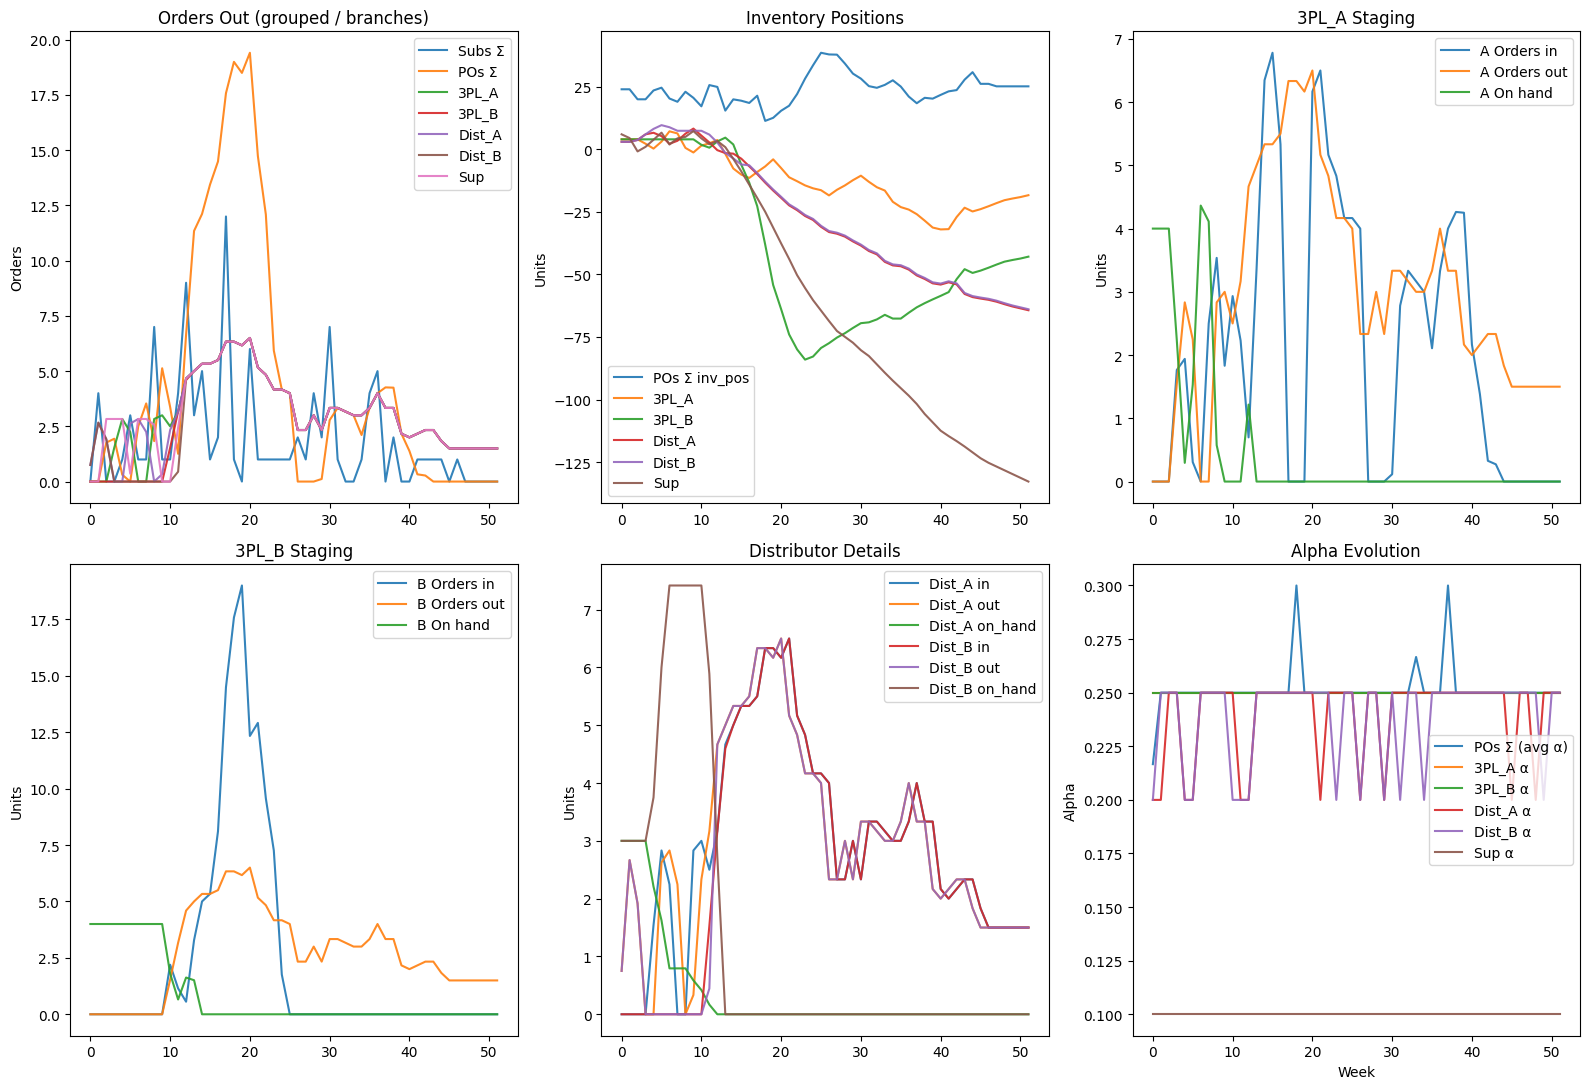

In [ ]:
# ===== Post-Run Diagnostics (multi-project, dual-3PL/Dist; hardened) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'hist_roles' in globals() and 'coeff_logs' in globals():
    # Infer horizon from any series instead of relying on horizonWeeks
    try:
        any_arr = next(iter(hist_roles["orders_out"].values()))
        T = len(any_arr)
    except Exception:
        print("hist_roles seems empty.")
        T = 0

    def _zeros(): return np.zeros(T, dtype=float)

    def _sum_series(keys):
        acc = None
        for k in keys or []:
            arr = np.asarray(hist_roles["orders_out"].get(k, _zeros()))
            acc = arr if acc is None else (acc + arr)
        return acc if acc is not None else _zeros()

    def _sum_hist(metric, keys):
        acc = None
        for k in keys or []:
            arr = np.asarray(hist_roles.get(metric, {}).get(k, _zeros()))
            acc = arr if acc is None else (acc + arr)
        return acc if acc is not None else _zeros()

    # Role groups present
    all_out = set(hist_roles.get("orders_out", {}).keys())
    SUBS  = sorted([k for k in all_out if k.startswith("Sub")])
    POS   = sorted([k for k in all_out if k.startswith("PO")])
    has_A = "3PL_A" in all_out; has_B = "3PL_B" in all_out
    has_DA = "Dist_A" in all_out; has_DB = "Dist_B" in all_out
    has_sup = "Sup" in all_out

    # Combined series
    orders_Sub_total = _sum_series(SUBS)
    orders_PO_total  = _sum_series(POS)
    orders_3PL_A     = hist_roles["orders_out"].get("3PL_A", _zeros())
    orders_3PL_B     = hist_roles["orders_out"].get("3PL_B", _zeros())
    orders_Dist_A    = hist_roles["orders_out"].get("Dist_A", _zeros())
    orders_Dist_B    = hist_roles["orders_out"].get("Dist_B", _zeros())
    orders_Sup       = hist_roles["orders_out"].get("Sup", _zeros()) if has_sup else _zeros()

    # -------- Order activity (group totals + branch breakdown) --------
    print("ORDER ACTIVITY (Totals):")
    def _stats(arr): return float(arr.sum()), int((arr > 0.1).sum()), float(arr.max()) if arr.size else 0.0
    rows = [
        ("Subs (Σ of 3)",) + _stats(orders_Sub_total),
        ("POs  (Σ of 3)",) + _stats(orders_PO_total),
    ]
    if has_A: rows.append(("3PL_A",) + _stats(orders_3PL_A))
    if has_B: rows.append(("3PL_B",) + _stats(orders_3PL_B))
    if has_DA: rows.append(("Dist_A",) + _stats(orders_Dist_A))
    if has_DB: rows.append(("Dist_B",) + _stats(orders_Dist_B))
    if has_sup: rows.append(("Sup",) + _stats(orders_Sup))
    print(pd.DataFrame(rows, columns=["Role/Group","Total","Active_wks","Max"])
            .to_string(index=False, float_format=lambda x: f"{x:6.1f}"))

    # Per-project PO/Sub quick view
    if SUBS and POS:
        print("\nPER-PROJECT ORDER ACTIVITY:")
        proj_rows = []
        for sub, po in zip(SUBS, POS):
            ts = hist_roles["orders_out"].get(sub, _zeros())
            tp = hist_roles["orders_out"].get(po,  _zeros())
            proj_rows.append((sub,) + _stats(ts))
            proj_rows.append((po,)  + _stats(tp))
        print(pd.DataFrame(proj_rows, columns=["Role","Total","Active_wks","Max"])
                .to_string(index=False, float_format=lambda x: f"{x:6.1f}"))

    # -------- Weekly patterns at key intervals (grouped) --------
    print("\nWEEKLY ORDER PATTERNS (grouped):")
    weeks_to_check = [w for w in [0,10,20,30,40,50] if w < T]
    rows = []
    for t in weeks_to_check:
        row = {"week": t, "Subs_Σ": orders_Sub_total[t], "POs_Σ": orders_PO_total[t]}
        if has_A:  row["3PL_A"]  = orders_3PL_A[t]
        if has_B:  row["3PL_B"]  = orders_3PL_B[t]
        if has_DA: row["Dist_A"] = orders_Dist_A[t]
        if has_DB: row["Dist_B"] = orders_Dist_B[t]
        if has_sup:row["Sup"]    = orders_Sup[t]
        rows.append(row)
    print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:6.1f}"))

    # -------- Inventory analysis for upstream roles (branch-aware) --------
    print("\nINVENTORY ANALYSIS:")
    for role in [r for r in ["3PL_A","3PL_B","Dist_A","Dist_B","Sup"] if r in all_out]:
        on  = hist_roles["on_hand"].get(role, _zeros())
        bkl = hist_roles["backlog"].get(role, _zeros())
        pip = hist_roles["pipeline"].get(role, _zeros())
        inv = on + pip - bkl
        if T > 20:
            print(f"\n{role}:")
            print(f"  Week 20: on_hand={on[20]:.1f}, backlog={bkl[20]:.1f}, pipeline={pip[20]:.1f}")
            print(f"  Week 20: inv_pos={inv[20]:.1f}")
        print(f"  Avg inventory (weeks 10..T): {on[min(10, T-1):].mean():.1f}")

    # -------- Coefficient analysis (averages) --------
    print("\nCOEFFICIENT ANALYSIS (averages across roles where applicable):")
    def _avg_coeffs(keys):
        a=s=l=0.0; ex=0; n=0
        for k in keys or []:
            logs = coeff_logs.get(k, [])
            if not logs: continue
            a += sum(c["alpha"] for c in logs)
            s += sum(c["service_level"] for c in logs)
            l += sum(c["lot_multiplier"] for c in logs)
            ex += sum(1 for c in logs if c["expedite"])
            n  += len(logs)
        if n == 0: return np.nan, np.nan, np.nan, 0
        return a/n, s/n, l/n, ex

    coeff_rows = [
        ("Subs_Σ",) + _avg_coeffs(SUBS),
        ("POs_Σ", ) + _avg_coeffs(POS),
    ]
    if has_A:  coeff_rows.append(("3PL_A",) + _avg_coeffs(["3PL_A"]))
    if has_B:  coeff_rows.append(("3PL_B",) + _avg_coeffs(["3PL_B"]))
    if has_DA: coeff_rows.append(("Dist_A",) + _avg_coeffs(["Dist_A"]))
    if has_DB: coeff_rows.append(("Dist_B",) + _avg_coeffs(["Dist_B"]))
    if has_sup:coeff_rows.append(("Sup",)    + _avg_coeffs(["Sup"]))
    print(pd.DataFrame(coeff_rows, columns=["Role/Group","alpha","service","lot_mult","expedites"])
            .to_string(index=False, float_format=lambda x: f"{x:6.2f}"))

    # -------- Supply chain flow snapshot (grouped) --------
    print("\nSUPPLY CHAIN FLOW (snapshot weeks):")
    flow_rows = []
    for t in [10, 20, 30, 40]:
        if t >= T: continue
        row = {
            "week": t,
            "Subs_out_Σ": orders_Sub_total[t],
            "PO_in_Σ": sum(hist_roles["orders_in"].get(po, _zeros())[t] for po in POS),
            "PO_out_Σ": orders_PO_total[t],
        }
        if has_A:  row |= {"3PL_A_in": hist_roles["orders_in"]["3PL_A"][t], "3PL_A_out": orders_3PL_A[t]}
        if has_B:  row |= {"3PL_B_in": hist_roles["orders_in"]["3PL_B"][t], "3PL_B_out": orders_3PL_B[t]}
        if has_DA: row |= {"Dist_A_in": hist_roles["orders_in"]["Dist_A"][t], "Dist_A_out": orders_Dist_A[t]}
        if has_DB: row |= {"Dist_B_in": hist_roles["orders_in"]["Dist_B"][t], "Dist_B_out": orders_Dist_B[t]}
        if has_sup:row |= {"Sup_in": hist_roles["orders_in"]["Sup"][t]}
        flow_rows.append(row)
    print(pd.DataFrame(flow_rows).to_string(index=False, float_format=lambda x: f"{x:6.1f}"))

    # -------- Plots --------
    plt.figure(figsize=(16, 11))

    # 1) Orders by group/branch
    ax = plt.subplot(2, 3, 1)
    ax.plot(orders_Sub_total, label="Subs Σ", alpha=0.9)
    ax.plot(orders_PO_total,  label="POs Σ",  alpha=0.9)
    if has_A:  ax.plot(orders_3PL_A, label="3PL_A", alpha=0.9)
    if has_B:  ax.plot(orders_3PL_B, label="3PL_B", alpha=0.9)
    if has_DA: ax.plot(orders_Dist_A, label="Dist_A", alpha=0.9)
    if has_DB: ax.plot(orders_Dist_B, label="Dist_B", alpha=0.9)
    if has_sup:ax.plot(orders_Sup, label="Sup", alpha=0.9)
    ax.set_title("Orders Out (grouped / branches)"); ax.set_ylabel("Orders"); ax.legend()

    # 2) Inventory positions (PO Σ, 3PL A/B, Dist A/B, Sup)
    ax = plt.subplot(2, 3, 2)
    if POS:
        invpos_PO = (_sum_hist("on_hand", POS) + _sum_hist("pipeline", POS) - _sum_hist("backlog", POS))
        ax.plot(invpos_PO, label="POs Σ inv_pos", alpha=0.9)
    for role in [r for r in ["3PL_A","3PL_B","Dist_A","Dist_B","Sup"] if r in all_out]:
        inv_pos = (hist_roles["on_hand"][role] + hist_roles["pipeline"][role] - hist_roles["backlog"][role])
        ax.plot(inv_pos, label=role, alpha=0.9)
    ax.set_title("Inventory Positions"); ax.set_ylabel("Units"); ax.legend()

    # 3) 3PL_A staging
    if has_A:
        ax = plt.subplot(2, 3, 3)
        ax.plot(hist_roles["orders_in"]["3PL_A"],  label="A Orders in",  alpha=0.9)
        ax.plot(hist_roles["orders_out"]["3PL_A"], label="A Orders out", alpha=0.9)
        ax.plot(hist_roles["on_hand"]["3PL_A"],    label="A On hand",    alpha=0.9)
        ax.set_title("3PL_A Staging"); ax.set_ylabel("Units"); ax.legend()

    # 4) 3PL_B staging
    if has_B:
        ax = plt.subplot(2, 3, 4)
        ax.plot(hist_roles["orders_in"]["3PL_B"],  label="B Orders in",  alpha=0.9)
        ax.plot(hist_roles["orders_out"]["3PL_B"], label="B Orders out", alpha=0.9)
        ax.plot(hist_roles["on_hand"]["3PL_B"],    label="B On hand",    alpha=0.9)
        ax.set_title("3PL_B Staging"); ax.set_ylabel("Units"); ax.legend()

    # 5) Distributor details
    if has_DA or has_DB:
        ax = plt.subplot(2, 3, 5)
        if has_DA:
            ax.plot(hist_roles["orders_in"]["Dist_A"],  label="Dist_A in",     alpha=0.9)
            ax.plot(hist_roles["orders_out"]["Dist_A"], label="Dist_A out",    alpha=0.9)
            ax.plot(hist_roles["on_hand"]["Dist_A"],    label="Dist_A on_hand",alpha=0.9)
        if has_DB:
            ax.plot(hist_roles["orders_in"]["Dist_B"],  label="Dist_B in",     alpha=0.9)
            ax.plot(hist_roles["orders_out"]["Dist_B"], label="Dist_B out",    alpha=0.9)
            ax.plot(hist_roles["on_hand"]["Dist_B"],    label="Dist_B on_hand",alpha=0.9)
        ax.set_title("Distributor Details"); ax.set_ylabel("Units"); ax.legend()

    # 6) Alpha evolution (PO avg + branches)
    ax = plt.subplot(2, 3, 6)
    def _alpha_series(keys):
        mats = []
        for k in keys or []:
            logs = coeff_logs.get(k, [])
            if logs:
                mats.append(np.array([c["alpha"] for c in logs], dtype=float))
        if not mats: return _zeros()
        maxlen = max(len(m) for m in mats)
        padded = [np.pad(m, (0, maxlen - len(m)), mode='edge') for m in mats]
        return np.vstack(padded).mean(axis=0)[:T]

    if POS:
        ax.plot(_alpha_series(POS), label="POs Σ (avg α)", alpha=0.9)
    for k in [x for x in ["3PL_A","3PL_B","Dist_A","Dist_B","Sup"] if x in coeff_logs]:
        series = np.array([c["alpha"] for c in coeff_logs[k]], dtype=float)
        ax.plot(series[:T], label=f"{k} α", alpha=0.9)
    ax.set_title("Alpha Evolution"); ax.set_ylabel("Alpha"); ax.set_xlabel("Week"); ax.legend()

    plt.tight_layout()
    plt.show()

else:
    print("Run the simulation first to generate hist_roles and coeff_logs data.")


Bullwhip metrics (post burn-in = 10):
  role  bullwhip_ratio_var  amplification_std  mean_ratio
 3PL_A               0.342              0.585       1.715
 3PL_B               0.351              0.592       1.702
Dist_A               0.343              0.586       1.713
Dist_B               0.407              0.638       1.652
   PO1               0.752              0.867       1.283
   PO2               0.819              0.905       0.749
   PO3               0.552              0.743       0.530
  Sub1               0.323              0.569       0.639
  Sub2               0.093              0.305       0.241
  Sub3               0.034              0.184       0.120
   Sup               0.382              0.618       1.676

Sample of coefficient choices:
 role  t  alpha  service_level  lot_multiplier  expedite
3PL_A  0   0.25            0.9             1.5     False
3PL_A  1   0.25            0.9             1.5     False
3PL_A  2   0.25            0.9             1.5     False
3PL_A 

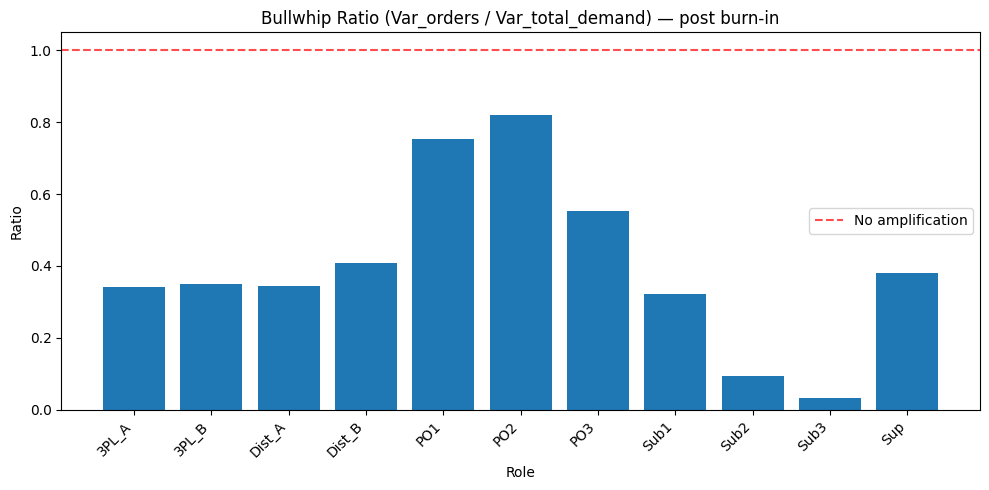

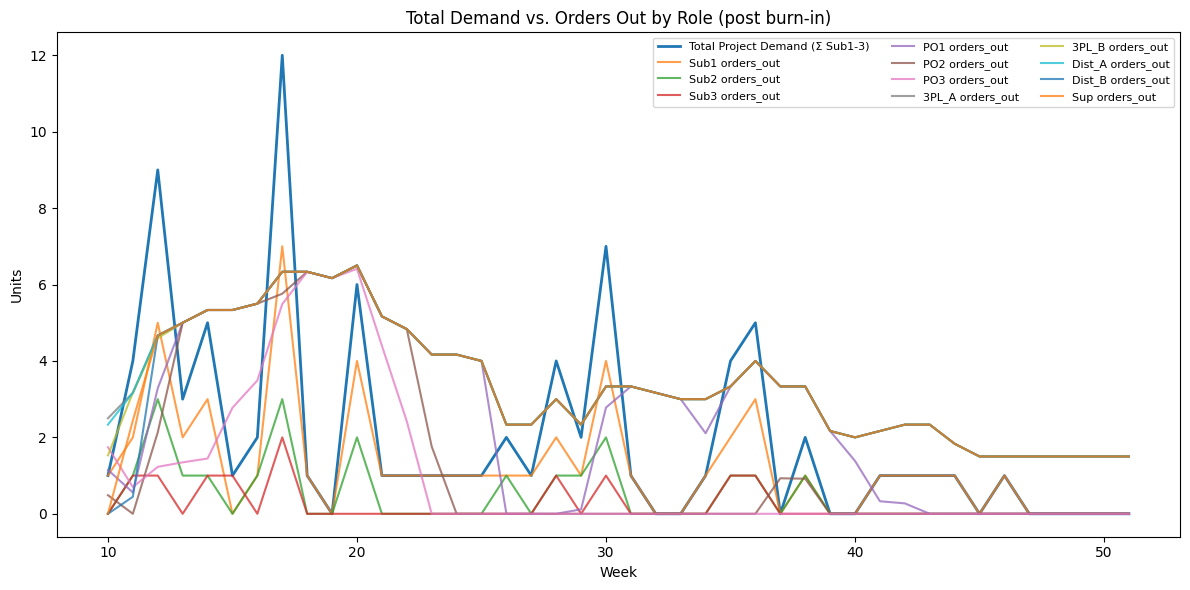

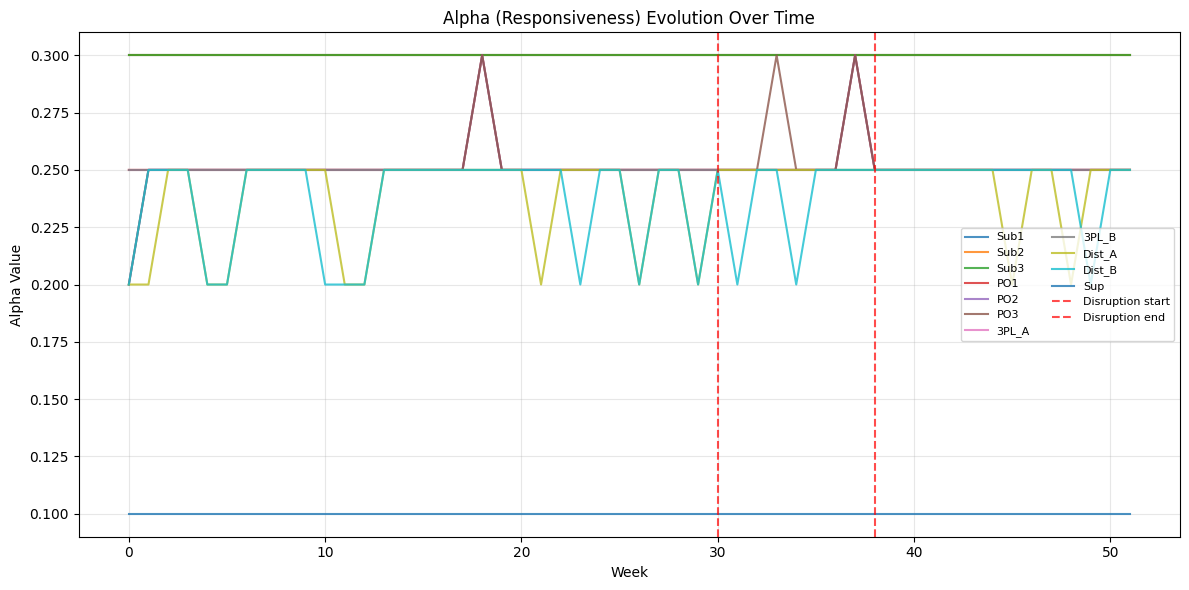

In [ ]:
# ===== R5 — KPIs + coefficient & sharing summaries (multi-project, dual branches) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

burnIn = 10

# --- Role groups taken from the run objects ---
SUBS   = [k for k in hist_roles["orders_out"].keys() if k.startswith("Sub")]
POS    = [k for k in hist_roles["orders_out"].keys() if k.startswith("PO")]
THREEP = [k for k in hist_roles["orders_out"].keys() if k.startswith("3PL_")]
DISTS  = [k for k in hist_roles["orders_out"].keys() if k.startswith("Dist_")]
SUPS   = ["Sup"]
ALL_ROLES = SUBS + POS + THREEP + DISTS + SUPS

# Roles that hold inventory / place orders
roles_holding = [r for r in ALL_ROLES]

# --- Demand: total customer demand across the three projects
# Uses the per-sub series defined in R1; assert the sum equals original total.
d_total = np.zeros(horizonWeeks, dtype=float)
for s in SUBS:
    d_total += np.asarray(customerDemand_by_sub[s], dtype=float)

try:
    assert np.allclose(d_total, customerDemand_total)
except Exception:
    pass

def compute_metrics_roles(hist, demand_series, roles, burnIn=0):
    rows = []
    cust = np.asarray(demand_series[burnIn:], dtype=float)
    var_cust = float(np.var(cust, ddof=0))
    std_cust = float(np.std(cust, ddof=0))
    mean_cust = float(np.mean(cust))

    for r in roles:
        orders = np.asarray(hist["orders_out"][r][burnIn:], dtype=float)
        var_orders = float(np.var(orders, ddof=0))
        std_orders = float(np.std(orders, ddof=0))
        mean_orders = float(np.mean(orders))

        rows.append({
            "role": r,
            "bullwhip_ratio_var": (var_orders / var_cust) if var_cust > 0 else np.nan,
            "amplification_std": (std_orders / std_cust) if std_cust > 0 else np.nan,
            "mean_ratio": (mean_orders / mean_cust) if mean_cust > 0 else np.nan,
        })
    return pd.DataFrame(rows).sort_values("role")

# ---- KPIs
df_kpi = compute_metrics_roles(hist_roles, d_total, roles_holding, burnIn=burnIn)
print(f"Bullwhip metrics (post burn-in = {burnIn}):")
print(df_kpi.to_string(index=False, float_format=lambda x: f"{x:0.3f}"))

# ---- Coefficient logs → DataFrame
rows = []
for r, logs in coeff_logs.items():
    for rec in logs:
        rows.append({
            "role": r,
            **{k: rec.get(k) for k in ("t","alpha","service_level","lot_multiplier","expedite")}
        })
coeff_df = pd.DataFrame(rows).sort_values(["role","t"])
print("\nSample of coefficient choices:")
print(coeff_df.head(18).to_string(index=False))

# Distributions by role
alpha_dist = coeff_df.groupby(["role","alpha"]).size().rename("count").reset_index()
sl_dist    = coeff_df.groupby(["role","service_level"]).size().rename("count").reset_index()
lot_dist   = coeff_df.groupby(["role","lot_multiplier"]).size().rename("count").reset_index()
exp_dist   = coeff_df.groupby(["role","expedite"]).size().rename("count").reset_index()

print("\nAlpha choices (counts):")
print(alpha_dist.pivot(index="role", columns="alpha", values="count").fillna(0).astype(int))
print("\nService level choices (counts):")
print(sl_dist.pivot(index="role", columns="service_level", values="count").fillna(0).astype(int))
print("\nLot multiplier choices (counts):")
print(lot_dist.pivot(index="role", columns="lot_multiplier", values="count").fillna(0).astype(int))
print("\nExpedite choices (counts):")
print(exp_dist.pivot(index="role", columns="expedite", values="count").fillna(0).astype(int))

# ---- Sharing policy changes summary
policy_rows = []
for r, logs in coeff_logs.items():
    add_total = sum(len(rec.get("share_add", [])) for rec in logs)
    drop_total = sum(len(rec.get("share_drop", [])) for rec in logs)
    policy_rows.append({"role": r, "share_add_total": add_total, "share_drop_total": drop_total})
df_policy = pd.DataFrame(policy_rows).sort_values("role")
print("\nSharing policy changes (totals over run):")
print(df_policy.to_string(index=False))

# Current published keys by role (from InfoBank policies)
current_share = {r: profiles[r].share_keys for r in ROLES}
print("\nCurrent share policy keys by role:")
for r in ROLES:
    print(f"  {r}: {current_share[r]}")

# ---- Enhanced Analysis tuned to new topology
print("\n=== MULTI-PROJECT, DUAL-BRANCH ANALYSIS ===")

# Role-specific coefficient averages
print("\nAverage coefficients by role:")
role_avg_coeffs = coeff_df.groupby("role")[["alpha", "service_level", "lot_multiplier"]].mean()
print(role_avg_coeffs.round(3))

# Expedite frequency by role
print("\nExpedite frequency by role:")
expedite_freq = coeff_df.groupby("role")["expedite"].mean()
print(expedite_freq.round(3))

# Pre-crisis vs Crisis vs Post-crisis comparison
periods = {
    "pre_crisis": (0, 30),
    "crisis": (30, 38),
    "post_crisis": (38, 52)
}

print("\nPeriod-based coefficient analysis:")
for period_name, (start, end) in periods.items():
    period_data = coeff_df[(coeff_df["t"] >= start) & (coeff_df["t"] < end)]
    if len(period_data) > 0:
        print(f"\n{period_name.upper()}:")
        period_avg = period_data.groupby("role")[["alpha", "service_level", "lot_multiplier"]].mean()
        print(period_avg.round(3))

# ---- Plots
# 1) Bullwhip ratio bar across all concrete roles
plt.figure(figsize=(10,5))
plt.bar(df_kpi["role"], df_kpi["bullwhip_ratio_var"])
plt.axhline(1.0, linestyle="--", color='red', alpha=0.7, label='No amplification')
plt.title("Bullwhip Ratio (Var_orders / Var_total_demand) — post burn-in")
plt.ylabel("Ratio"); plt.xlabel("Role")
plt.xticks(rotation=45, ha='right')
plt.legend(); plt.tight_layout(); plt.show()

# 2) Orders_out vs. total customer demand (post burn-in)
t_idx = np.arange(horizonWeeks)
plt.figure(figsize=(12,6))
plt.plot(t_idx[burnIn:], d_total[burnIn:], label="Total Project Demand (Σ Sub1-3)", linewidth=2)
for r in roles_holding:
    plt.plot(t_idx[burnIn:], hist_roles["orders_out"][r][burnIn:], label=f"{r} orders_out", alpha=0.75)
plt.title("Total Demand vs. Orders Out by Role (post burn-in)")
plt.xlabel("Week"); plt.ylabel("Units")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

# 3) Alpha evolution by role
plt.figure(figsize=(12,6))
for r in roles_holding:
    if r in coeff_logs and coeff_logs[r]:
        times = [rec["t"] for rec in coeff_logs[r]]
        alphas = [rec["alpha"] for rec in coeff_logs[r]]
        plt.plot(times, alphas, label=f"{r}", alpha=0.8)
plt.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Disruption start')
plt.axvline(x=38, color='red', linestyle='--', alpha=0.7, label='Disruption end')
plt.title("Alpha (Responsiveness) Evolution Over Time")
plt.xlabel("Week"); plt.ylabel("Alpha Value")
plt.legend(fontsize=8, ncol=2); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ---- Optional: save summaries
# coeff_df.to_csv("coeff_choices_multi.csv", index=False)
# df_kpi.to_csv("kpi_bullwhip_multi.csv", index=False)
# df_policy.to_csv("sharing_changes_multi.csv", index=False)


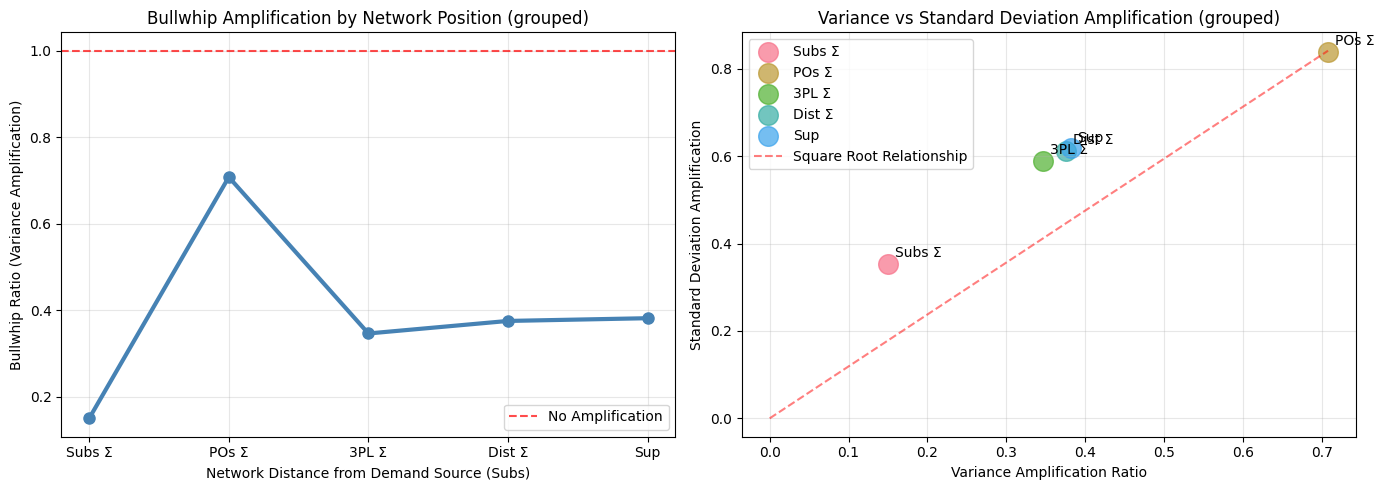

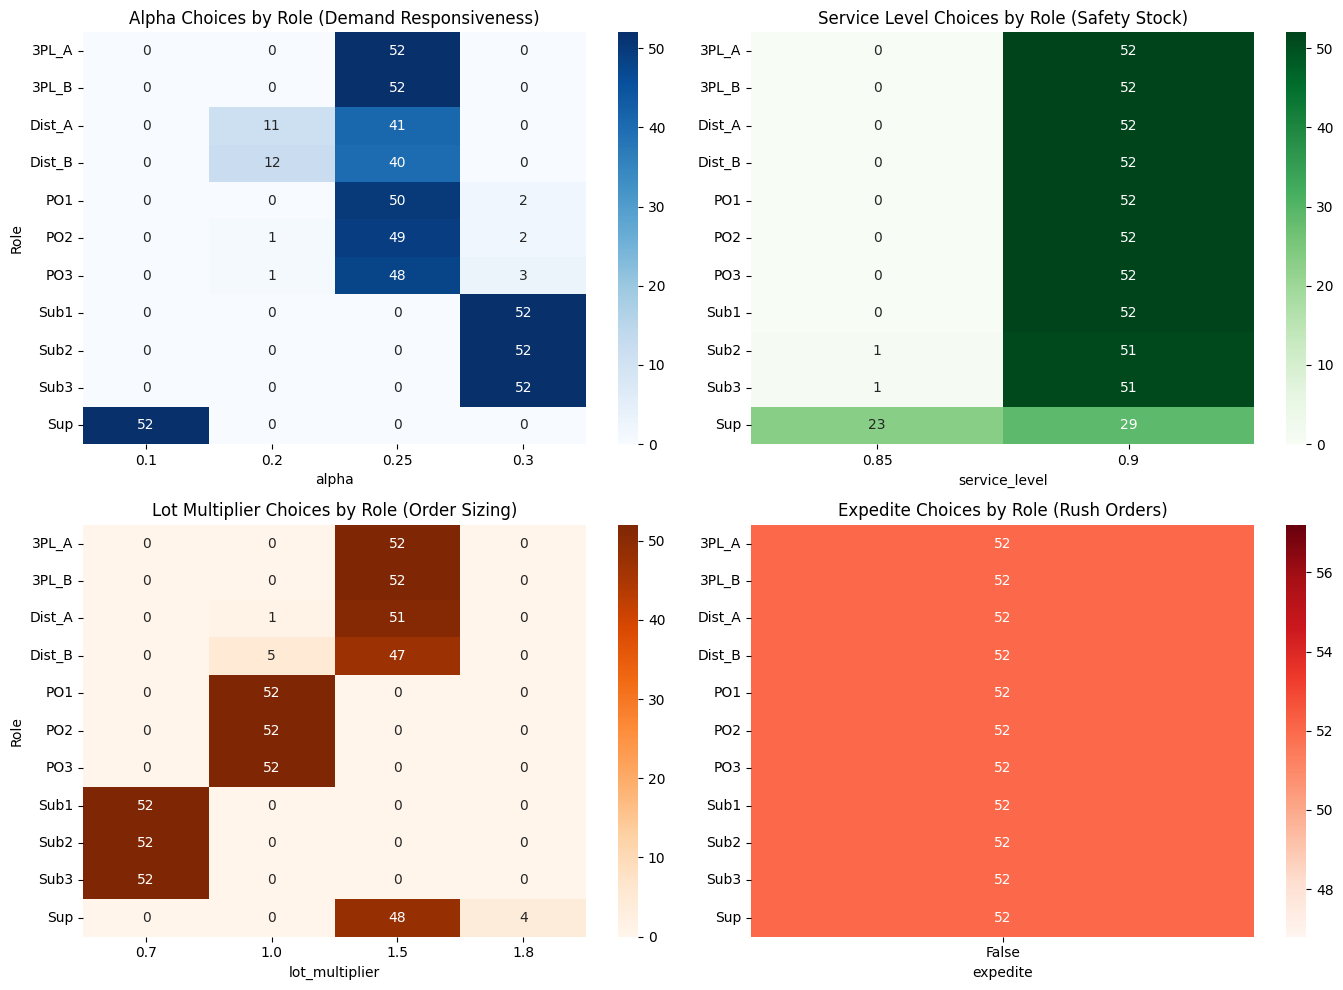

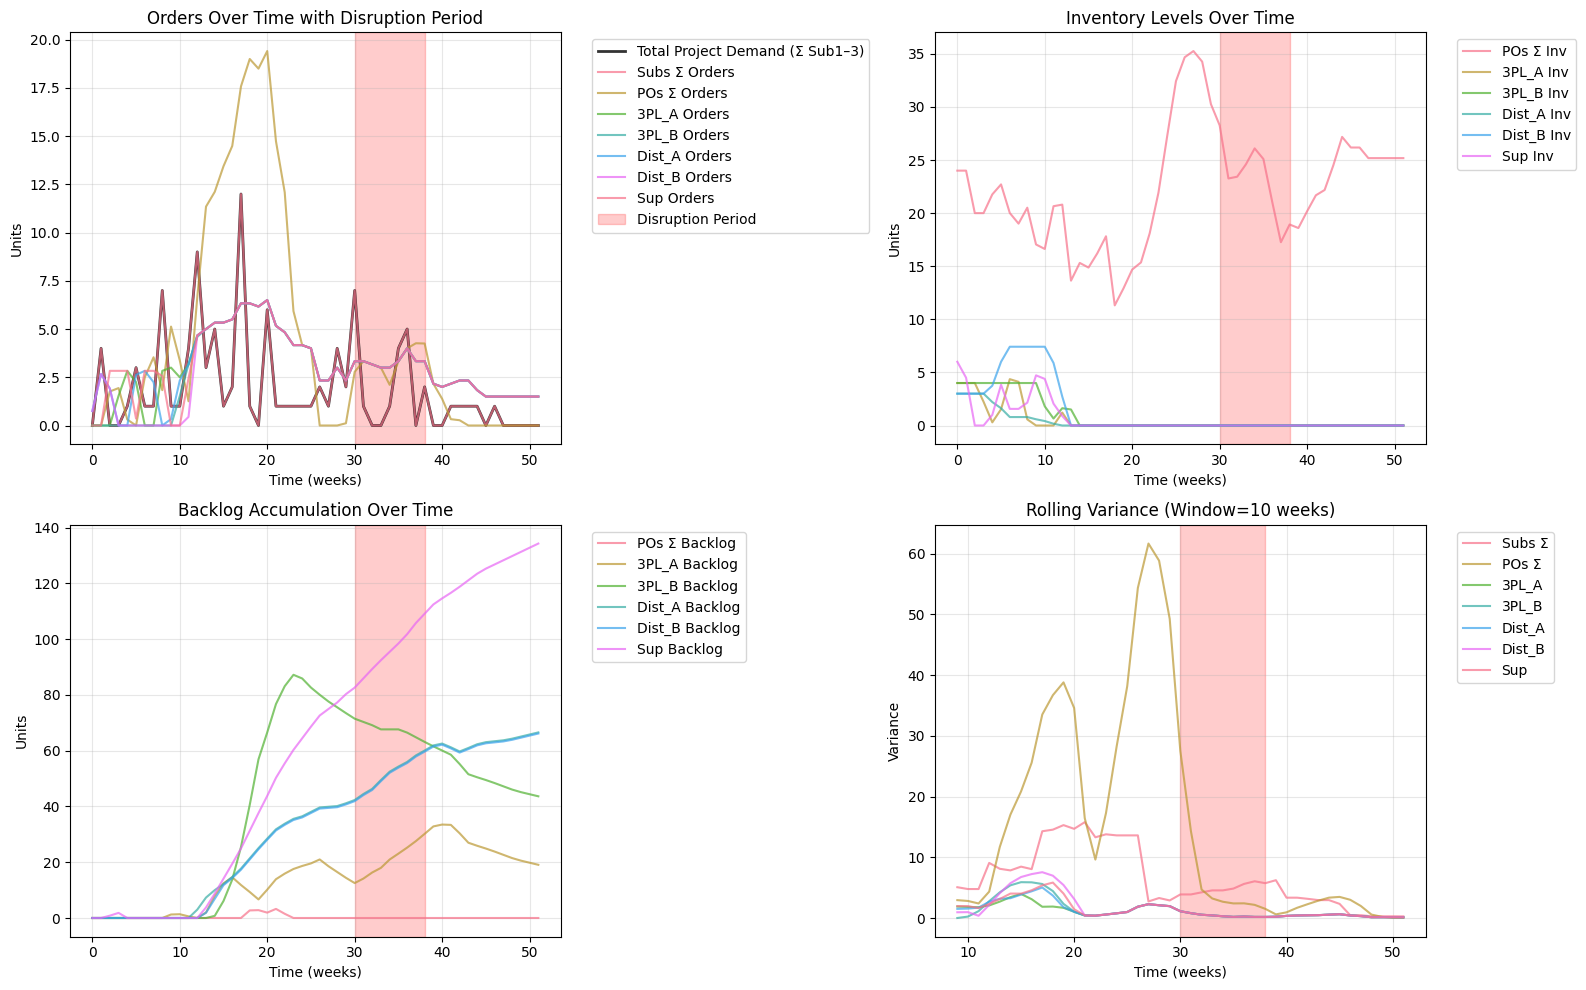

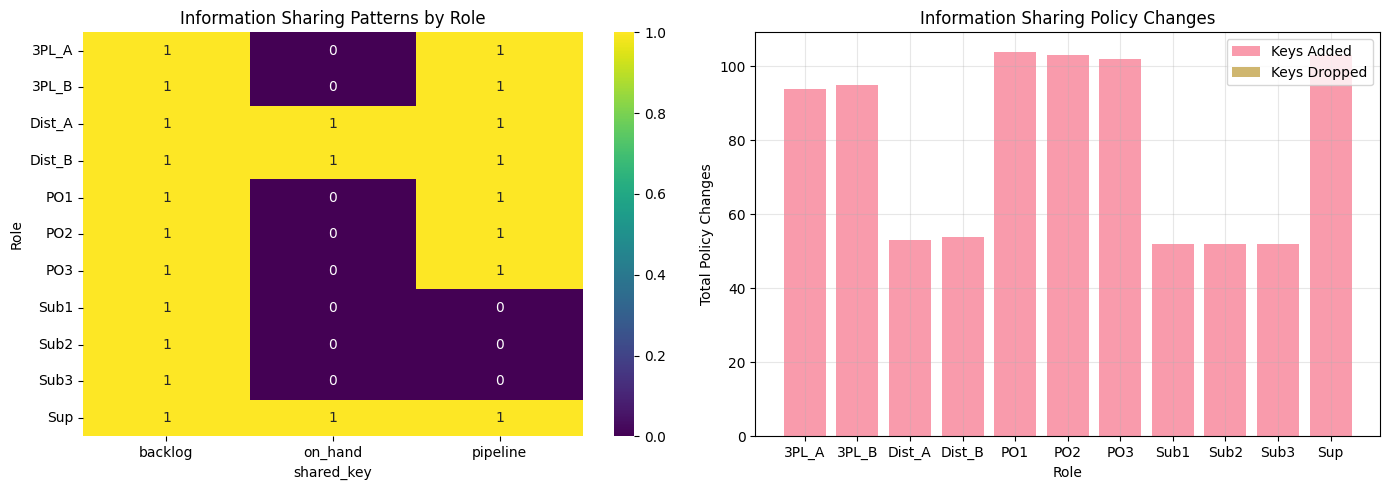

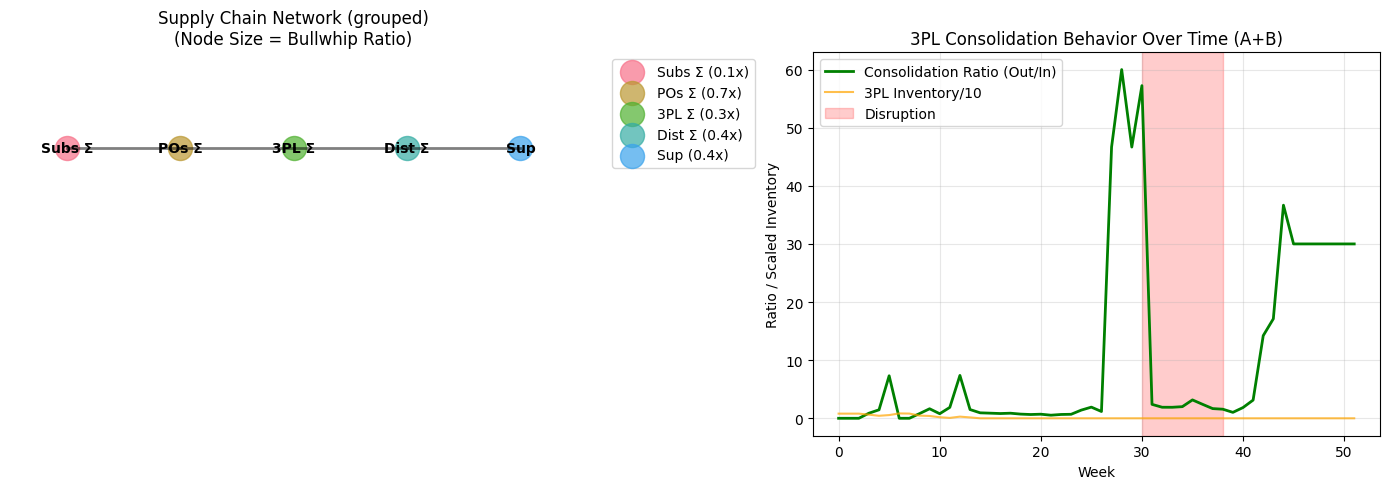

/tmp/ipython-input-2626956373.py:248: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([alpha_data[r] for r in labels], labels=labels)


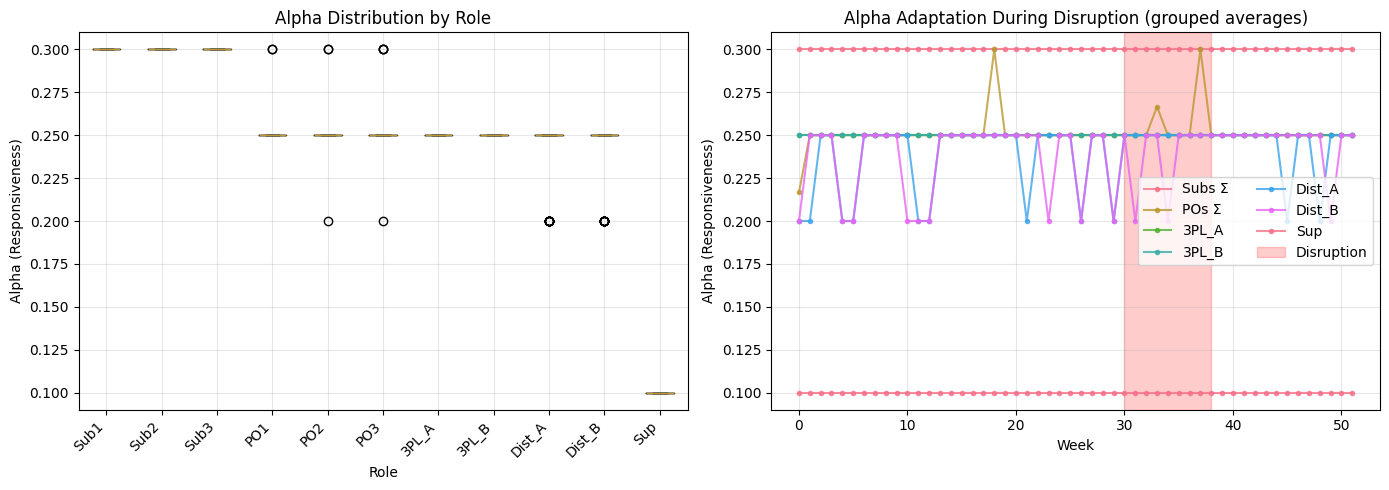

In [ ]:
# ===== Comprehensive Visualizations for Construction Supply Chain Research (multi-project, dual-branch) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# --- helpers / role groups from run objects ---
SUBS   = [k for k in hist_roles["orders_out"].keys() if k.startswith("Sub")]
POS    = [k for k in hist_roles["orders_out"].keys() if k.startswith("PO")]
THREEP = ["3PL_A","3PL_B"]
DISTS  = ["Dist_A","Dist_B"]
SUPS   = ["Sup"]

def _sum_hist(metric, keys):
    acc = np.zeros(horizonWeeks, dtype=float)
    for k in keys:
        acc += np.asarray(hist_roles[metric].get(k, np.zeros(horizonWeeks)), dtype=float)
    return acc

# Total customer demand across projects (for lines/axes below)
d_total = np.zeros(horizonWeeks, dtype=float)
for s in SUBS:
    d_total += np.asarray(customerDemand_by_sub[s], dtype=float)

# Set style for publication-quality plots
plt.style.use('default')
sns.set_palette("husl")

# 1) BULLWHIP CASCADE ANALYSIS (grouped by network position)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

roles_grouped = {
    "Subs Σ":  SUBS,
    "POs Σ":   POS,
    "3PL Σ":   THREEP,
    "Dist Σ":  DISTS,
    "Sup":     SUPS,
}

# Group bullwhip by mean over members
bw_vals, std_vals = [], []
for lbl, members in roles_grouped.items():
    df_sub = df_kpi[df_kpi["role"].isin(members)]
    bw_vals.append(float(df_sub["bullwhip_ratio_var"].mean()))
    std_vals.append(float(df_sub["amplification_std"].mean()))

network_distances = list(range(len(roles_grouped)))  # 0..4
ordered_labels = list(roles_grouped.keys())

ax1.plot(network_distances, bw_vals, 'o-', linewidth=3, markersize=8, color='steelblue')
ax1.set_xlabel('Network Distance from Demand Source (Subs)')
ax1.set_ylabel('Bullwhip Ratio (Variance Amplification)')
ax1.set_title('Bullwhip Amplification by Network Position (grouped)')
ax1.set_xticks(network_distances)
ax1.set_xticklabels(ordered_labels, rotation=0)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='No Amplification')
ax1.legend()

# Mean vs Standard Deviation scatter (group points)
for i, lbl in enumerate(ordered_labels):
    ax2.scatter(bw_vals[i], std_vals[i], s=200, alpha=0.7, label=lbl)
    ax2.annotate(lbl, (bw_vals[i], std_vals[i]), xytext=(5,5), textcoords='offset points')

ax2.set_xlabel('Variance Amplification Ratio')
ax2.set_ylabel('Standard Deviation Amplification')
ax2.set_title('Variance vs Standard Deviation Amplification (grouped)')
ax2.grid(True, alpha=0.3)
ax2.plot([0, max(bw_vals)], [0, max(bw_vals)**0.5], 'r--', alpha=0.5, label='Square Root Relationship')
ax2.legend()

plt.tight_layout()
plt.show()

# 2) COEFFICIENT CHOICE HEATMAP BY ROLE (works as-is on concrete roles)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

alpha_pivot = alpha_dist.pivot(index="role", columns="alpha", values="count").fillna(0).astype(int)
sns.heatmap(alpha_pivot, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Alpha Choices by Role (Demand Responsiveness)')
ax1.set_ylabel('Role')

sl_pivot = sl_dist.pivot(index="role", columns="service_level", values="count").fillna(0).astype(int)
sns.heatmap(sl_pivot, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Service Level Choices by Role (Safety Stock)')
ax2.set_ylabel('')

lot_pivot = lot_dist.pivot(index="role", columns="lot_multiplier", values="count").fillna(0).astype(int)
sns.heatmap(lot_pivot, annot=True, fmt='d', cmap='Oranges', ax=ax3)
ax3.set_title('Lot Multiplier Choices by Role (Order Sizing)')
ax3.set_ylabel('Role')

exp_pivot = exp_dist.pivot(index="role", columns="expedite", values="count").fillna(0).astype(int)
sns.heatmap(exp_pivot, annot=True, fmt='d', cmap='Reds', ax=ax4)
ax4.set_title('Expedite Choices by Role (Rush Orders)')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()

# 3) TIME SERIES DECOMPOSITION WITH DISRUPTION (use grouped series)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

t_idx = np.arange(horizonWeeks)
disruption_start = 30
disruption_end   = 38

# Orders over time with disruption marker
ax1.plot(t_idx, d_total, 'k-', linewidth=2, label='Total Project Demand (Σ Sub1–3)', alpha=0.8)
ax1.plot(t_idx, _sum_hist("orders_out", SUBS),  label='Subs Σ Orders', alpha=0.7)
ax1.plot(t_idx, _sum_hist("orders_out", POS),   label='POs Σ Orders', alpha=0.7)
ax1.plot(t_idx, _sum_hist("orders_out", ["3PL_A"]), label='3PL_A Orders', alpha=0.7)
ax1.plot(t_idx, _sum_hist("orders_out", ["3PL_B"]), label='3PL_B Orders', alpha=0.7)
ax1.plot(t_idx, _sum_hist("orders_out", ["Dist_A"]), label='Dist_A Orders', alpha=0.7)
ax1.plot(t_idx, _sum_hist("orders_out", ["Dist_B"]), label='Dist_B Orders', alpha=0.7)
ax1.plot(t_idx, _sum_hist("orders_out", SUPS),  label='Sup Orders', alpha=0.7)
ax1.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption Period')
ax1.set_title('Orders Over Time with Disruption Period')
ax1.set_xlabel('Time (weeks)'); ax1.set_ylabel('Units')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left'); ax1.grid(True, alpha=0.3)

# Inventory levels over time (grouped)
ax2.plot(t_idx, _sum_hist("on_hand", POS), label='POs Σ Inv', alpha=0.7)
ax2.plot(t_idx, hist_roles["on_hand"]["3PL_A"], label='3PL_A Inv', alpha=0.7)
ax2.plot(t_idx, hist_roles["on_hand"]["3PL_B"], label='3PL_B Inv', alpha=0.7)
ax2.plot(t_idx, hist_roles["on_hand"]["Dist_A"], label='Dist_A Inv', alpha=0.7)
ax2.plot(t_idx, hist_roles["on_hand"]["Dist_B"], label='Dist_B Inv', alpha=0.7)
ax2.plot(t_idx, hist_roles["on_hand"]["Sup"],   label='Sup Inv', alpha=0.7)
ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax2.set_title('Inventory Levels Over Time')
ax2.set_xlabel('Time (weeks)'); ax2.set_ylabel('Units')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left'); ax2.grid(True, alpha=0.3)

# Backlog accumulation
ax3.plot(t_idx, _sum_hist("backlog", POS), label='POs Σ Backlog', alpha=0.7)
ax3.plot(t_idx, hist_roles["backlog"]["3PL_A"], label='3PL_A Backlog', alpha=0.7)
ax3.plot(t_idx, hist_roles["backlog"]["3PL_B"], label='3PL_B Backlog', alpha=0.7)
ax3.plot(t_idx, hist_roles["backlog"]["Dist_A"], label='Dist_A Backlog', alpha=0.7)
ax3.plot(t_idx, hist_roles["backlog"]["Dist_B"], label='Dist_B Backlog', alpha=0.7)
ax3.plot(t_idx, hist_roles["backlog"]["Sup"],   label='Sup Backlog', alpha=0.7)
ax3.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax3.set_title('Backlog Accumulation Over Time')
ax3.set_xlabel('Time (weeks)'); ax3.set_ylabel('Units')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left'); ax3.grid(True, alpha=0.3)

# Rolling variance (bullwhip over time) — grouped
window = 10
def _roll_var(a, w=10):
    s = pd.Series(a)
    return s.rolling(w).var().to_numpy()

ax4.plot(t_idx, _roll_var(_sum_hist("orders_out", SUBS), window), label='Subs Σ', alpha=0.7)
ax4.plot(t_idx, _roll_var(_sum_hist("orders_out", POS),  window), label='POs Σ', alpha=0.7)
ax4.plot(t_idx, _roll_var(hist_roles["orders_out"]["3PL_A"], window), label='3PL_A', alpha=0.7)
ax4.plot(t_idx, _roll_var(hist_roles["orders_out"]["3PL_B"], window), label='3PL_B', alpha=0.7)
ax4.plot(t_idx, _roll_var(hist_roles["orders_out"]["Dist_A"], window), label='Dist_A', alpha=0.7)
ax4.plot(t_idx, _roll_var(hist_roles["orders_out"]["Dist_B"], window), label='Dist_B', alpha=0.7)
ax4.plot(t_idx, _roll_var(hist_roles["orders_out"]["Sup"], window), label='Sup', alpha=0.7)
ax4.axvspan(disruption_start, disruption_end, alpha=0.2, color='red')
ax4.set_title(f'Rolling Variance (Window={window} weeks)')
ax4.set_xlabel('Time (weeks)'); ax4.set_ylabel('Variance')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left'); ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4) INFORMATION SHARING ANALYSIS (unchanged, just uses current_share/df_policy you already computed)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sharing_data = []
for role in ROLES:
    for key in current_share[role]:
        sharing_data.append({"role": role, "shared_key": key})
sharing_df = pd.DataFrame(sharing_data)

if not sharing_df.empty:
    sharing_counts = sharing_df.groupby(["role", "shared_key"]).size().reset_index(name="count")
    sharing_pivot = sharing_counts.pivot(index="role", columns="shared_key", values="count").fillna(0).astype(int)
    sns.heatmap(sharing_pivot, annot=True, fmt='d', cmap='viridis', ax=ax1)
ax1.set_title('Information Sharing Patterns by Role'); ax1.set_ylabel('Role')

ax2.bar(df_policy["role"], df_policy["share_add_total"], alpha=0.7, label='Keys Added')
ax2.bar(df_policy["role"], df_policy["share_drop_total"], alpha=0.7, label='Keys Dropped')
ax2.set_title('Information Sharing Policy Changes')
ax2.set_xlabel('Role'); ax2.set_ylabel('Total Policy Changes')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5) NETWORK STRUCTURE VISUALIZATION (grouped nodes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

positions = {"Subs Σ": (0, 1), "POs Σ": (1, 1), "3PL Σ": (2, 1), "Dist Σ": (3, 1), "Sup": (4, 1)}
bullwhip_dict = dict(zip(ordered_labels, bw_vals))

for role, (x, y) in positions.items():
    if role in bullwhip_dict:
        size = max(300, bullwhip_dict[role] * 50)
        ax1.scatter(x, y, s=size, alpha=0.7, label=f'{role} ({bullwhip_dict[role]:.1f}x)')
        ax1.annotate(role, (x, y), ha='center', va='center', fontweight='bold')

connections = [("Subs Σ", "POs Σ"), ("POs Σ", "3PL Σ"), ("3PL Σ", "Dist Σ"), ("Dist Σ", "Sup")]
for start, end in connections:
    x1, y1 = positions[start]; x2, y2 = positions[end]
    ax1.plot([x1, x2], [y1, y2], 'k-', alpha=0.5, linewidth=2)

ax1.set_title('Supply Chain Network (grouped)\n(Node Size = Bullwhip Ratio)')
ax1.set_xlim(-0.5, 4.5); ax1.set_ylim(-0.5, 1.5)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left'); ax1.axis('off')

# 3PL Consolidation Analysis — use TOTAL across A & B
consolidation_data = []
orders_in_3pl_total  = _sum_hist("orders_in",  THREEP)
orders_out_3pl_total = _sum_hist("orders_out", THREEP)
onhand_3pl_total     = _sum_hist("on_hand",    THREEP)

for t in range(horizonWeeks):
    denom = max(orders_in_3pl_total[t], 0.1)
    consolidation_data.append({
        "week": t,
        "3PL_in": orders_in_3pl_total[t],
        "3PL_out": orders_out_3pl_total[t],
        "3PL_inventory": onhand_3pl_total[t],
        "consolidation_ratio": orders_out_3pl_total[t] / denom
    })

consol_df = pd.DataFrame(consolidation_data)
ax2.plot(consol_df["week"], consol_df["consolidation_ratio"], 'g-', linewidth=2, label='Consolidation Ratio (Out/In)')
ax2.plot(consol_df["week"], consol_df["3PL_inventory"]/10, 'orange', alpha=0.7, label='3PL Inventory/10')
ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption')
ax2.set_title('3PL Consolidation Behavior Over Time (A+B)')
ax2.set_xlabel('Week'); ax2.set_ylabel('Ratio / Scaled Inventory')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6) ROLE-SPECIFIC ALPHA STRATEGIES (concrete roles, not grouped)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

alpha_roles = SUBS + POS + THREEP + DISTS + SUPS
alpha_data = {r: [c["alpha"] for c in coeff_logs.get(r, [])] for r in alpha_roles if r in coeff_logs and coeff_logs[r]}

# Boxplot (only roles with data)
labels = list(alpha_data.keys())
ax1.boxplot([alpha_data[r] for r in labels], labels=labels)
ax1.set_title('Alpha Distribution by Role')
ax1.set_ylabel('Alpha (Responsiveness)'); ax1.set_xlabel('Role')
ax1.grid(True, alpha=0.3); plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Alpha evolution during disruption (average per group to declutter)
def _alpha_series_avg(keys):
    mats = []
    for k in keys:
        if k in coeff_logs and coeff_logs[k]:
            mats.append(np.array([c["alpha"] for c in coeff_logs[k]], dtype=float))
    if not mats:
        return np.zeros(horizonWeeks)
    M = np.vstack([m[:horizonWeeks] for m in mats])
    # pad shorter series if necessary
    min_len = min(m.shape[0] for m in mats)
    M = np.vstack([m[:min_len] for m in mats])
    return M.mean(axis=0)

group_alpha = {
    "Subs Σ": _alpha_series_avg(SUBS),
    "POs Σ":  _alpha_series_avg(POS),
    "3PL_A":  _alpha_series_avg(["3PL_A"]),
    "3PL_B":  _alpha_series_avg(["3PL_B"]),
    "Dist_A": _alpha_series_avg(["Dist_A"]),
    "Dist_B": _alpha_series_avg(["Dist_B"]),
    "Sup":    _alpha_series_avg(["Sup"]),
}

for lbl, series in group_alpha.items():
    ax2.plot(range(series.shape[0]), series, 'o-', label=lbl, alpha=0.8, markersize=3)

ax2.axvspan(disruption_start, disruption_end, alpha=0.2, color='red', label='Disruption')
ax2.set_title('Alpha Adaptation During Disruption (grouped averages)')
ax2.set_xlabel('Week'); ax2.set_ylabel('Alpha (Responsiveness)')
ax2.legend(ncol=2); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
